<a href="https://colab.research.google.com/github/shoopy7/shoopy7/blob/main/Clustering%2C_Analyzing%2C_%26_Exploring_Fundraising%2C_Donor_Trends_for_a_Nonprofit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering, Analyzing, & Exploring Fundraising, Donor Trends for a Nonprofit

Created in collaboration with OpenAI ChatGPT & Google Gemini

### Why?

Since AHA is a nonprofit, fundraising and donor engagement are crucial. Analyzing donation trends could show your ability to provide strategic insights.


NOTE:  This is PART 2 of a multi-part notebook


# Data

## data collection sources

* Part 2
  * Donor data is SYNTHETIC data created here in the notebook for this project

# libraries

In [1]:
#Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# use xml data from propublica website
import xml.etree.ElementTree as ET

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# clustering and segmentation with Kmeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import silhouette_score

# Generating Synthetic Donor Data



In [ ]:
# # Create a synthetic dataset
# num_donors = 1000  # Adjust as needed
# donor_data = {
#     'Donor ID': np.arange(1, num_donors + 1),
#     'Age': np.random.randint(18, 80, num_donors),
#     'Donation Amount': np.random.normal(200, 100, num_donors).clip(10, 10000),  # Mean of $200, min $10, max $10K
#     'Donation Frequency': np.random.choice(['One-time', 'Monthly', 'Annually'], num_donors, p=[0.6, 0.3, 0.1]),
#     'Region': np.random.choice(['North', 'South', 'East', 'West'], num_donors),
#     'Donor Type': np.random.choice(['Individual', 'Corporate', 'Foundation'], num_donors, p=[0.7, 0.2, 0.1])
# }

# # Convert to DataFrame
# df_donors = pd.DataFrame(donor_data)
# df_donors.head()

,Donor ID,Age,Donation Amount,Donation Frequency,Region,Donor Type
0,1,26,159.599941,Annually,South,Corporate
1,2,32,110.187413,One-time,North,Individual
2,3,59,176.516877,One-time,West,Foundation
3,4,77,331.299792,One-time,North,Individual
4,5,47,25.627251,One-time,East,Individual


In [ ]:
# # Creates an empty DataFrame. If re-running
# df_donors = pd.DataFrame()
# df_donors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of synthetic donors
num_donors = 1000

# Generate donor data
donor_data = {
    'Donor ID': np.arange(1, num_donors + 1),
    'Age': np.random.randint(18, 80, num_donors),
    'Donation Amount': np.random.normal(200, 100, num_donors).clip(10, 10000),
    'Donation Frequency': np.random.choice(['One-time', 'Monthly', 'Annually'], num_donors, p=[0.6, 0.3, 0.1]),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], num_donors),
    'Donor Type': np.random.choice(['Individual', 'Corporate', 'Foundation'], num_donors, p=[0.7, 0.2, 0.1]),
    # NEW FEATURES added
    'Total Donations': np.random.randint(1, 50, num_donors),  # Total number of donations made
    'Years Donating': np.random.randint(1, 20, num_donors),  # Number of years they have donated
    'Preferred Payment Method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer', 'Cryptocurrency'], num_donors, p=[0.5, 0.3, 0.15, 0.05]),
    'Engagement Level': np.random.choice(['Low', 'Medium', 'High'], num_donors, p=[0.4, 0.4, 0.2]),
    'Email Open Rate': np.random.uniform(0, 1, num_donors)  # Percentage of emails they open
}

# Convert to DataFrame
df_donors = pd.DataFrame(donor_data)

# Display first few rows
df_donors.head()


,Donor ID,Age,Donation Amount,Donation Frequency,Region,Donor Type,Total Donations,Years Donating,Preferred Payment Method,Engagement Level,Email Open Rate
0,1,56,337.237780,Annually,North,Individual,34,12,Credit Card,High,0.857917
1,2,69,132.221391,One-time,East,Individual,4,17,Credit Card,Low,0.298548
2,3,46,315.353187,Monthly,West,Corporate,17,3,PayPal,Medium,0.923743
3,4,32,162.498937,Monthly,North,Individual,4,11,PayPal,High,0.229806
4,5,60,130.585405,One-time,North,Individual,43,17,Credit Card,Low,0.749516


NOTES:

Start with a simple synthetic donor dataset and then build on it.

Generate 1,000 donors with these attributes as columns


## exploration of synthetic data created

### sanity checks

In [3]:
# check column names before function
print(df_donors.columns)

# standardize the column names
# Function to clean column names
def clean_column_names(df):
    df.columns = (df.columns
                  .str.lower()  # Convert to lowercase
                  .str.replace(r'[^\w\s]', '', regex=True)  # Remove punctuation
                  .str.replace(r'\s+', '_', regex=True)  # Replace spaces with underscores
                  .str.rstrip('_'))  # Remove trailing underscores
    return df

# Apply the function
df_donors = clean_column_names(df_donors)

# Print cleaned column names
print(df_donors.columns)


Index(['Donor ID', 'Age', 'Donation Amount', 'Donation Frequency', 'Region',
       'Donor Type', 'Total Donations', 'Years Donating',
       'Preferred Payment Method', 'Engagement Level', 'Email Open Rate'],
      dtype='object')
Index(['donor_id', 'age', 'donation_amount', 'donation_frequency', 'region',
       'donor_type', 'total_donations', 'years_donating',
       'preferred_payment_method', 'engagement_level', 'email_open_rate'],
      dtype='object')


In [4]:
df_donors.shape

(1000, 11)

In [5]:
df_donors.head()

,donor_id,age,donation_amount,donation_frequency,region,donor_type,total_donations,years_donating,preferred_payment_method,engagement_level,email_open_rate
0,1,56,337.237780,Annually,North,Individual,34,12,Credit Card,High,0.857917
1,2,69,132.221391,One-time,East,Individual,4,17,Credit Card,Low,0.298548
2,3,46,315.353187,Monthly,West,Corporate,17,3,PayPal,Medium,0.923743
3,4,32,162.498937,Monthly,North,Individual,4,11,PayPal,High,0.229806
4,5,60,130.585405,One-time,North,Individual,43,17,Credit Card,Low,0.749516


In [6]:
df_donors.tail()

,donor_id,age,donation_amount,donation_frequency,region,donor_type,total_donations,years_donating,preferred_payment_method,engagement_level,email_open_rate
995,996,18,302.615428,One-time,East,Individual,42,4,PayPal,Medium,0.026298
996,997,35,229.144992,One-time,West,Individual,19,18,PayPal,High,0.261029
997,998,49,126.931804,One-time,East,Corporate,17,9,Credit Card,Medium,0.538068
998,999,64,180.219531,Monthly,South,Individual,44,18,Credit Card,Low,0.907616
999,1000,66,162.024266,One-time,North,Individual,33,14,PayPal,Medium,0.846435


In [7]:
df_donors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   donor_id                  1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   donation_amount           1000 non-null   float64
 3   donation_frequency        1000 non-null   object 
 4   region                    1000 non-null   object 
 5   donor_type                1000 non-null   object 
 6   total_donations           1000 non-null   int64  
 7   years_donating            1000 non-null   int64  
 8   preferred_payment_method  1000 non-null   object 
 9   engagement_level          1000 non-null   object 
 10  email_open_rate           1000 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [8]:
#check for number of unique values for each column/feature
df_donors.nunique()

,0
donor_id,1000
age,62
donation_amount,961
donation_frequency,3
region,4
donor_type,3
total_donations,49
years_donating,19
preferred_payment_method,4
engagement_level,3


Table of the number of unique values for each column.

In [9]:
# checking for duplicate values in the data, summed
df_donors.duplicated().sum()

np.int64(0)

There are no duplicates in the synthetic dataset.

### EDA

In [10]:
# df_donors.info()

In [11]:
# define a list of columns with categorical values
count_cats = ['donation_frequency','region','donor_type',
              'preferred_payment_method','engagement_level']

# iterate over the columns and print the value counts and percentages for columns with encoded values
for col in count_cats:
  print(f"\nValue counts for column '{col}':")
  print(df_donors[col].value_counts().reset_index(name='Count'))
  print(f"\nPercentages:")
  print((df_donors[col].value_counts() / df_donors[col].shape[0]) * 100)
  print('*'*50)


Value counts for column 'donation_frequency':
  donation_frequency  Count
0           One-time    591
1            Monthly    314
2           Annually     95

Percentages:
donation_frequency
One-time    59.1
Monthly     31.4
Annually     9.5
Name: count, dtype: float64
**************************************************

Value counts for column 'region':
  region  Count
0  North    276
1   East    255
2  South    238
3   West    231

Percentages:
region
North    27.6
East     25.5
South    23.8
West     23.1
Name: count, dtype: float64
**************************************************

Value counts for column 'donor_type':
   donor_type  Count
0  Individual    701
1   Corporate    202
2  Foundation     97

Percentages:
donor_type
Individual    70.1
Corporate     20.2
Foundation     9.7
Name: count, dtype: float64
**************************************************

Value counts for column 'preferred_payment_method':
  preferred_payment_method  Count
0              Credit Card    492
1 

In [12]:
# summary statistics of numeric variables, transposed
df_donors.describe().T

,count,mean,std,min,25%,50%,75%,max
donor_id,1000.0,500.500000,288.819436,1.000000,250.750000,500.500000,750.250000,1000.000000
age,1000.0,49.857000,18.114267,18.000000,35.000000,50.000000,66.000000,79.000000
donation_amount,1000.0,206.220127,102.973809,10.000000,137.220361,206.643091,276.319852,517.444214
total_donations,1000.0,25.096000,13.885662,1.000000,14.000000,25.000000,37.000000,49.000000
years_donating,1000.0,9.914000,5.453654,1.000000,5.000000,10.000000,15.000000,19.000000
email_open_rate,1000.0,0.507534,0.292443,0.001356,0.261308,0.499549,0.762677,0.999741


Summary statistics for the numeric columns.

##### function

In [13]:
# function to create histograms with box plots for univariate analysis
def histogram_boxplot(data, feature, figsize=(5, 3), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (8,6))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

####univariate analysis:  visuals

In [15]:
# df_donors.info()

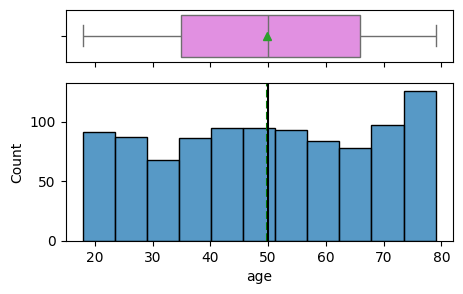

In [16]:
#visualize Age column histogram and distribution
histogram_boxplot(df_donors,'age', bins=11)

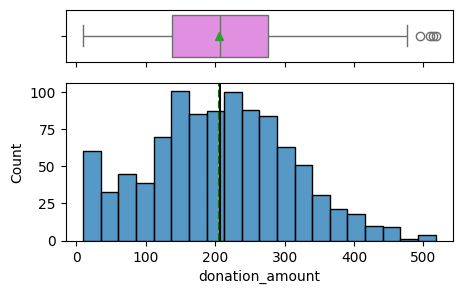

In [17]:
#visualize column histogram and distribution
histogram_boxplot(df_donors,'donation_amount', bins=20)

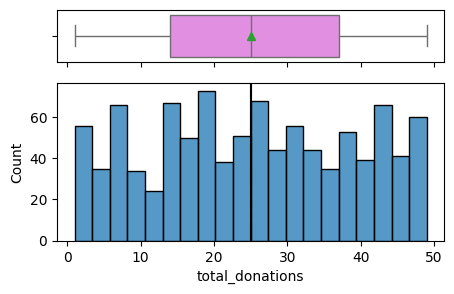

In [20]:
#visualize column histogram and distribution
histogram_boxplot(df_donors,'total_donations', bins=20)

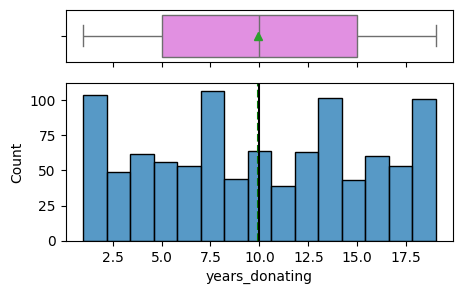

In [21]:
#visualize column histogram and distribution
histogram_boxplot(df_donors,'years_donating', bins=15)

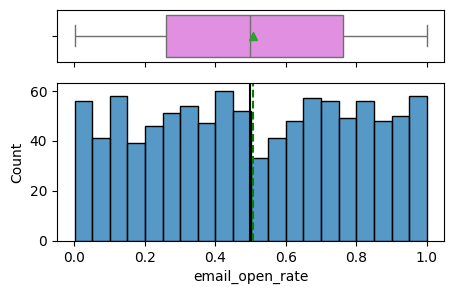

In [ ]:
#visualize column histogram and distribution
histogram_boxplot(df_donors,'email_open_rate', bins=20)

##### function

In [46]:
# function to create labeled barplots for univariate analysis
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count, 4))
    else:
        plt.figure(figsize=(n, 4))

    plt.xticks(rotation=90, fontsize=10)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=9,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### categorical data

<ipython-input-46-4e07c381ee41>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


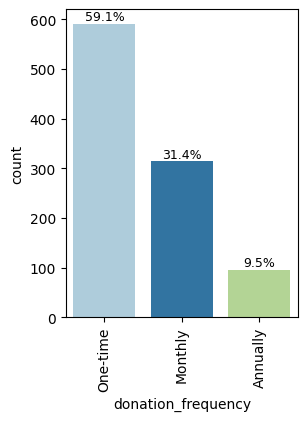

In [47]:
#visualize column bar graph
labeled_barplot(df_donors,'donation_frequency',perc=True)

<ipython-input-46-4e07c381ee41>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


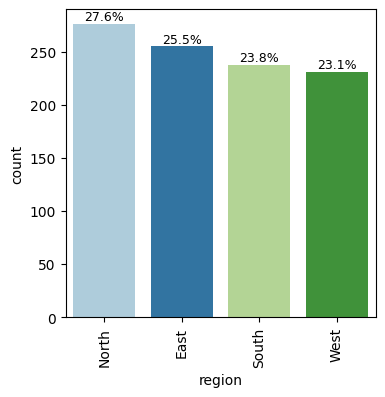

In [48]:
#visualize column bar graph
labeled_barplot(df_donors,'region',perc=True)

<ipython-input-46-4e07c381ee41>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


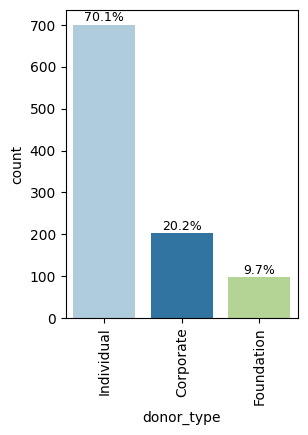

In [49]:
#visualize column bar graph
labeled_barplot(df_donors,'donor_type',perc=True)

<ipython-input-46-4e07c381ee41>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


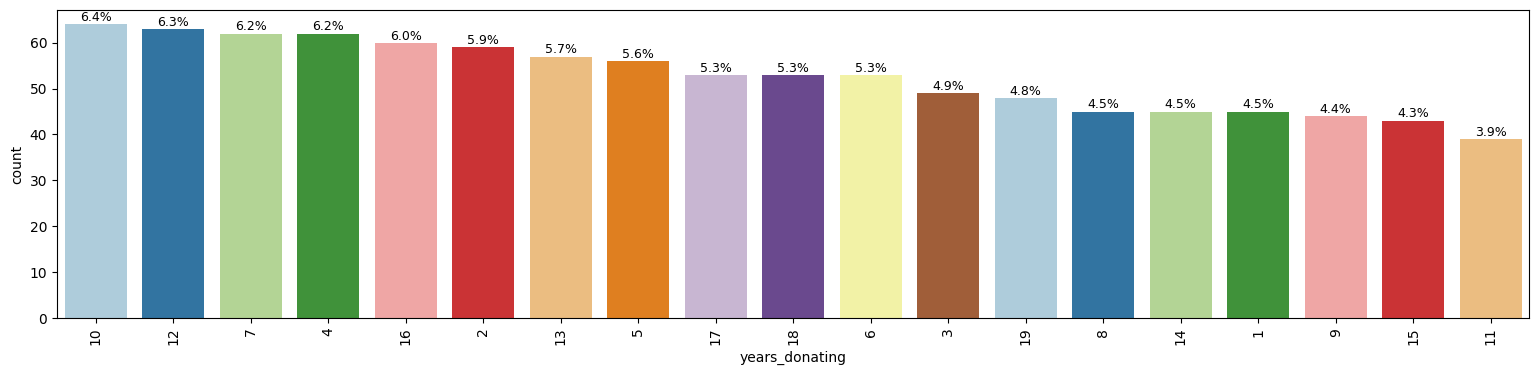

In [50]:
#visualize column bar graph
labeled_barplot(df_donors,'years_donating',perc=True)

<ipython-input-46-4e07c381ee41>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


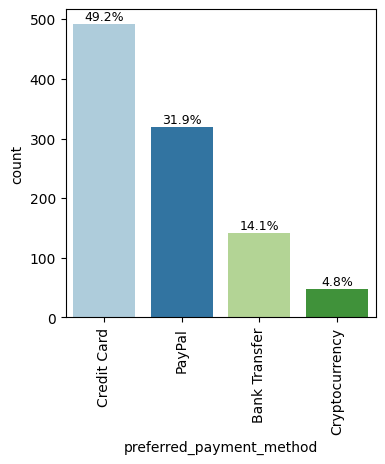

In [51]:
#visualize column bar graph
labeled_barplot(df_donors,'preferred_payment_method',perc=True)

<ipython-input-46-4e07c381ee41>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


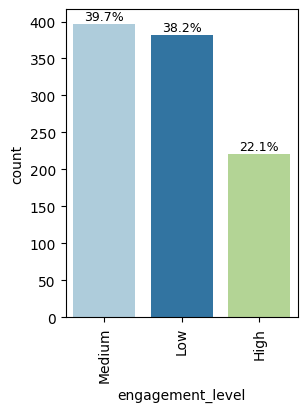

In [52]:
#visualize column bar graph
labeled_barplot(df_donors,'engagement_level',perc=True)

Observations:
* Looking at median and mean of the numeric columns, there are not outliers to analyze or treat.

####bivariate analysis (with predictor variable):  visuals

##### function

In [53]:
# function to create stacked barplots for mulitvariate analysis
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count, 3))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### stacked barplot with target variable hue

engagement_level  High  Low  Medium   All
age                                      
All                221  382     397  1000
53                   8    3       8    19
66                   8    3      11    22
77                   8   12       5    25
68                   7    3       5    15
..                 ...  ...     ...   ...
55                   1    5       3     9
51                   1    3       4     8
57                   1    6       6    13
27                   0    6       4    10
76                   0    9       4    13

[63 rows x 4 columns]
------------------------------------------------------------------------------------------------------------------------


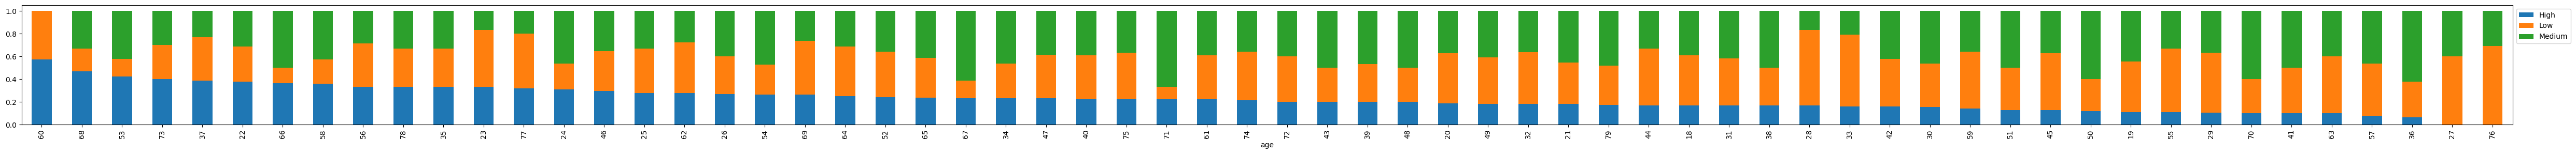

In [55]:
# visualization
stacked_barplot(df_donors, 'age', 'engagement_level')

engagement_level    High  Low  Medium   All
donation_frequency                         
All                  221  382     397  1000
One-time             134  231     226   591
Monthly               67  118     129   314
Annually              20   33      42    95
------------------------------------------------------------------------------------------------------------------------


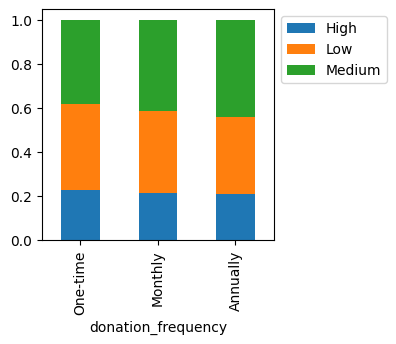

In [56]:
# visualization
stacked_barplot(df_donors, 'donation_frequency', 'engagement_level')

engagement_level  High  Low  Medium   All
region                                   
All                221  382     397  1000
West                63   94      74   231
North               56  100     120   276
South               52   95      91   238
East                50   93     112   255
------------------------------------------------------------------------------------------------------------------------


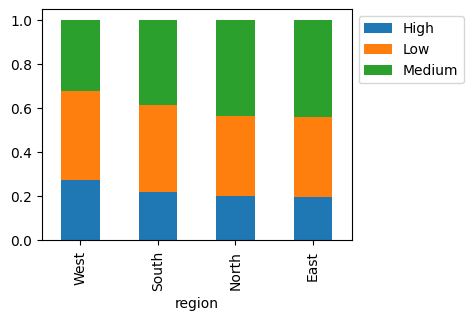

In [57]:
# visualization
stacked_barplot(df_donors, 'region', 'engagement_level')

engagement_level  High  Low  Medium   All
donor_type                               
All                221  382     397  1000
Individual         159  258     284   701
Corporate           49   72      81   202
Foundation          13   52      32    97
------------------------------------------------------------------------------------------------------------------------


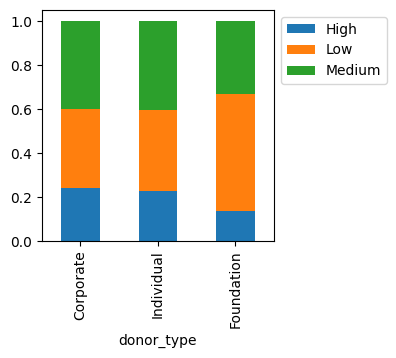

In [59]:
# visualization
stacked_barplot(df_donors, 'donor_type', 'engagement_level')

engagement_level          High  Low  Medium   All
preferred_payment_method                         
All                        221  382     397  1000
Credit Card                121  182     189   492
PayPal                      57  136     126   319
Bank Transfer               26   53      62   141
Cryptocurrency              17   11      20    48
------------------------------------------------------------------------------------------------------------------------


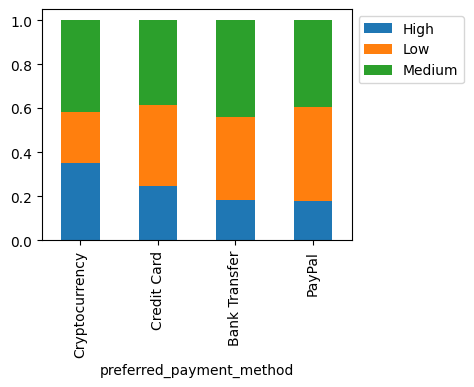

In [60]:
# visualization
stacked_barplot(df_donors, 'preferred_payment_method', 'engagement_level')

In [61]:
# df_donors.info()

pairplot (bivariate) without target variable in hue and correlation table of all numeric cols

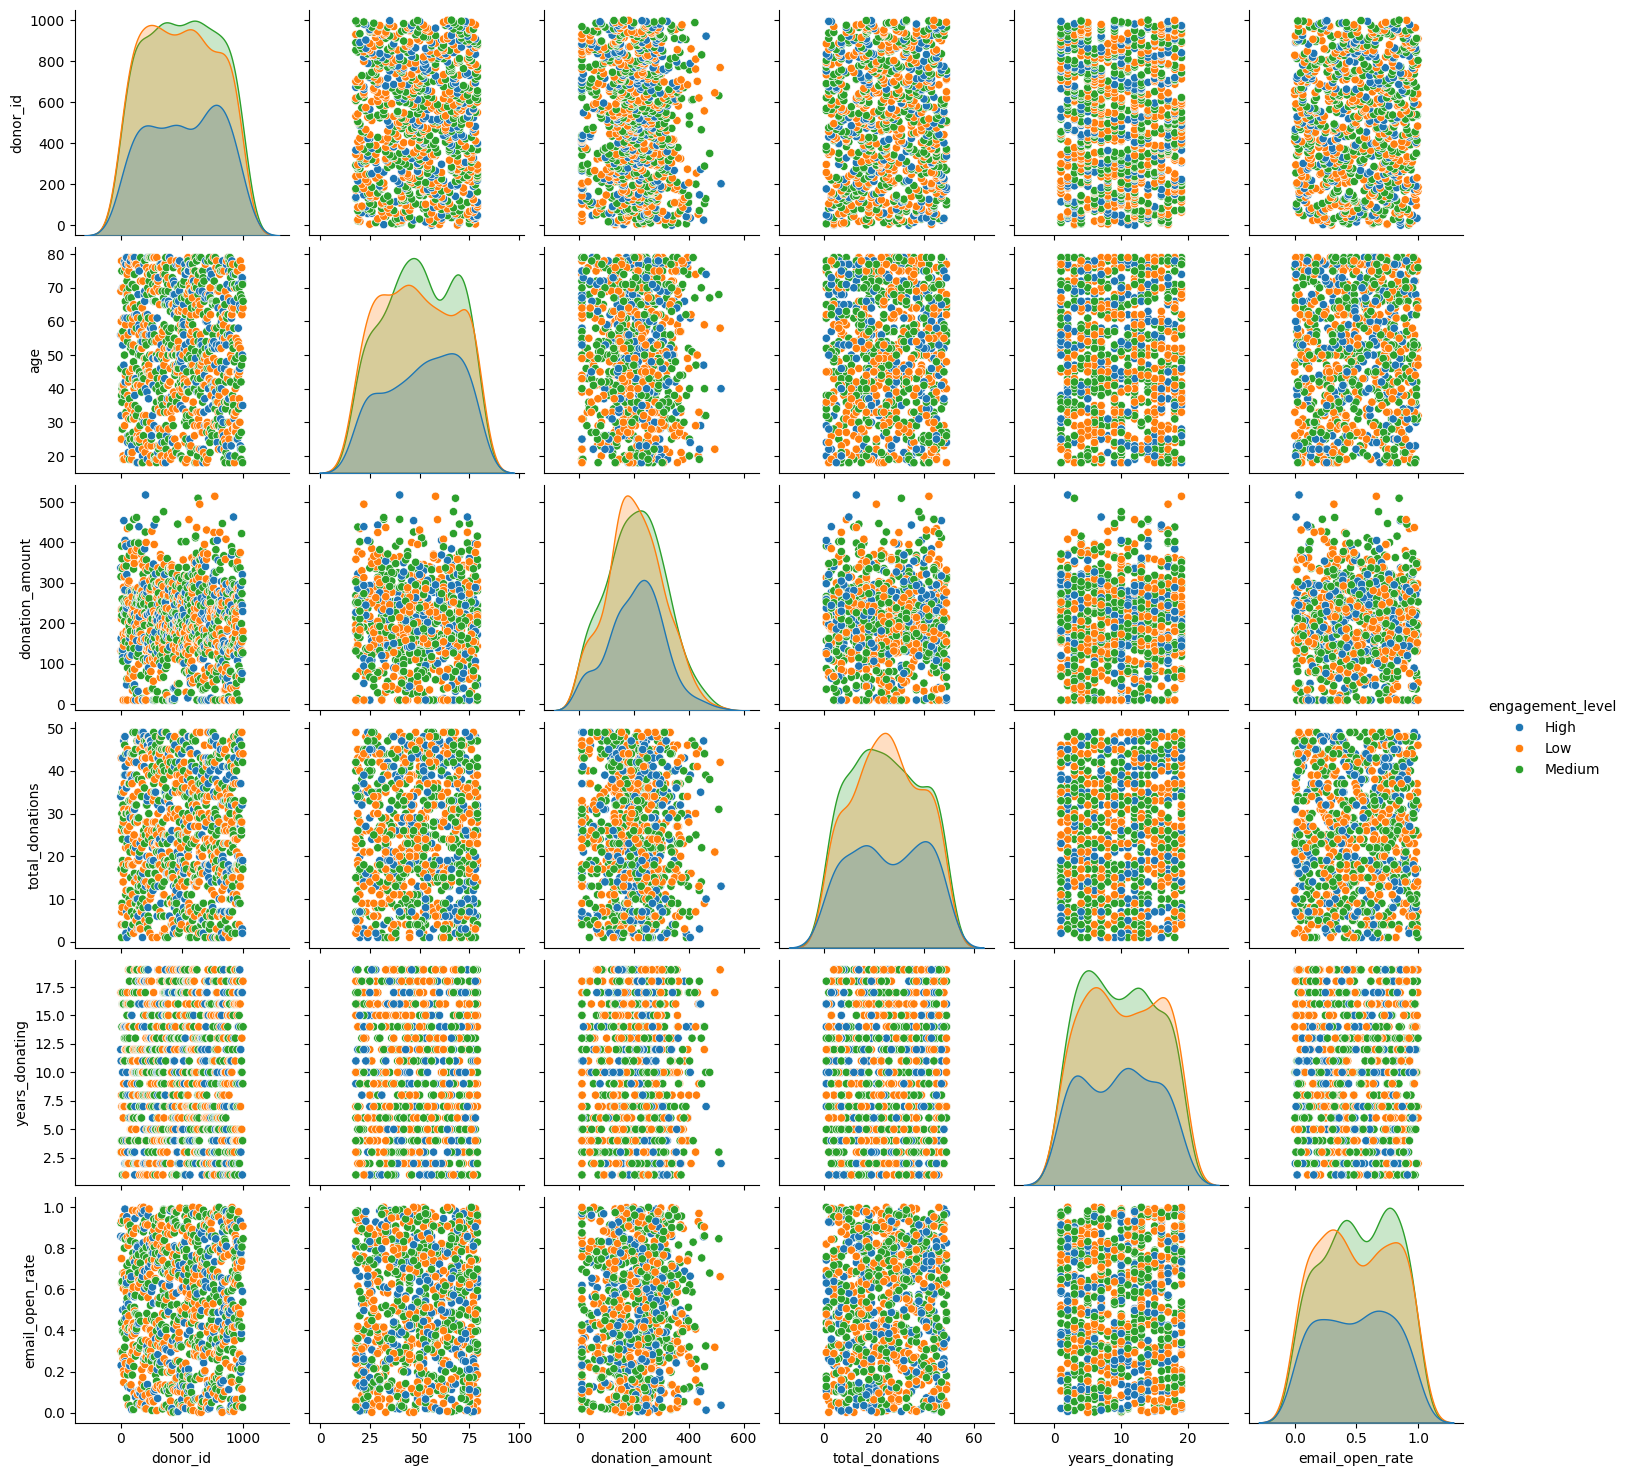

In [ ]:
# plot the variable distributions together and to see if any patterns appear with another variable
sns.pairplot(df_donors,hue = 'engagement_level', diag_kind='kde');  #hue = column that is the target variable, y, variable of interest

In [63]:
#define numeric columns # or use count_cats if defined above  ??untested
num_cols = ['age','donation_amount','total_donations','years_donating','email_open_rate']
# or use count_cats if defined above  ??untested

# Return correlation matrix for the numeric columns
correlation_matrix = df_donors[num_cols].corr()

# Display the correlation matrix
correlation_matrix

,age,donation_amount,total_donations,years_donating,email_open_rate
age,1.000000,-0.008806,0.003115,0.010819,0.052356
donation_amount,-0.008806,1.000000,0.006722,0.042073,0.045260
total_donations,0.003115,0.006722,1.000000,-0.027042,0.025080
years_donating,0.010819,0.042073,-0.027042,1.000000,-0.012935
email_open_rate,0.052356,0.045260,0.025080,-0.012935,1.000000


heatmap of correlations between pairings of all numeric cols in data set

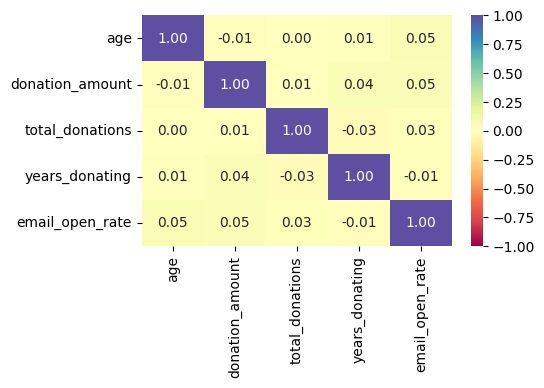

In [64]:
# plot a heatmap to visualize correlations between variables
plt.figure(figsize=(5, 3))
sns.heatmap(correlation_matrix, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral");
plt.show();

### multivariate analysis (with a predictor variable):  visuals

##### function

In [86]:
# ### function to plot distributions wrt target, used in Appendix
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(9, 7))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="pastel")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="pastel",
    )

    plt.tight_layout()
    plt.show()

#### plot distributions

<ipython-input-86-4171c9f0f443>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="pastel")
<ipython-input-86-4171c9f0f443>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


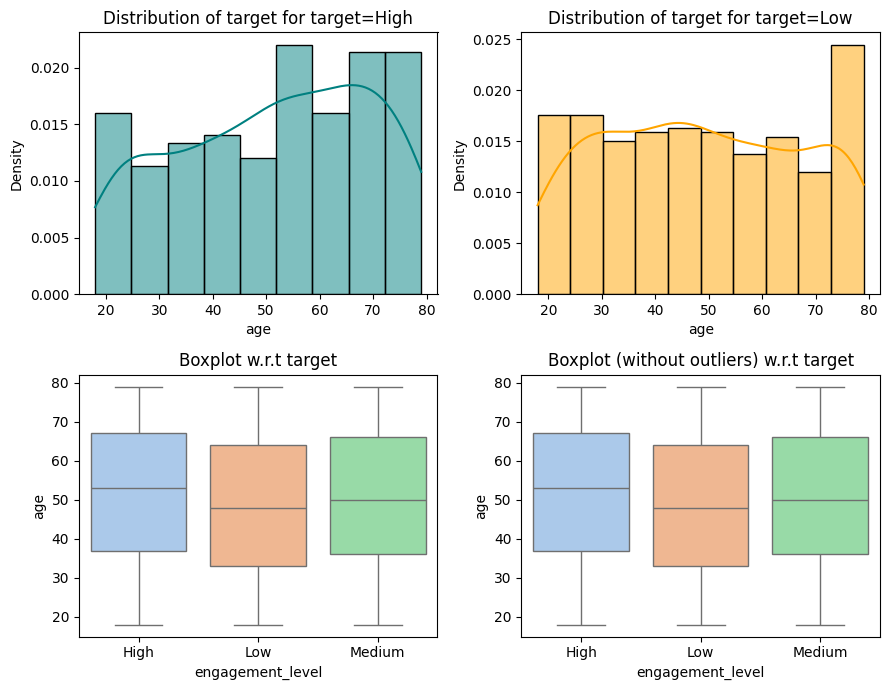

In [87]:
distribution_plot_wrt_target(df_donors, "age", "engagement_level")

<ipython-input-86-4171c9f0f443>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="pastel")
<ipython-input-86-4171c9f0f443>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


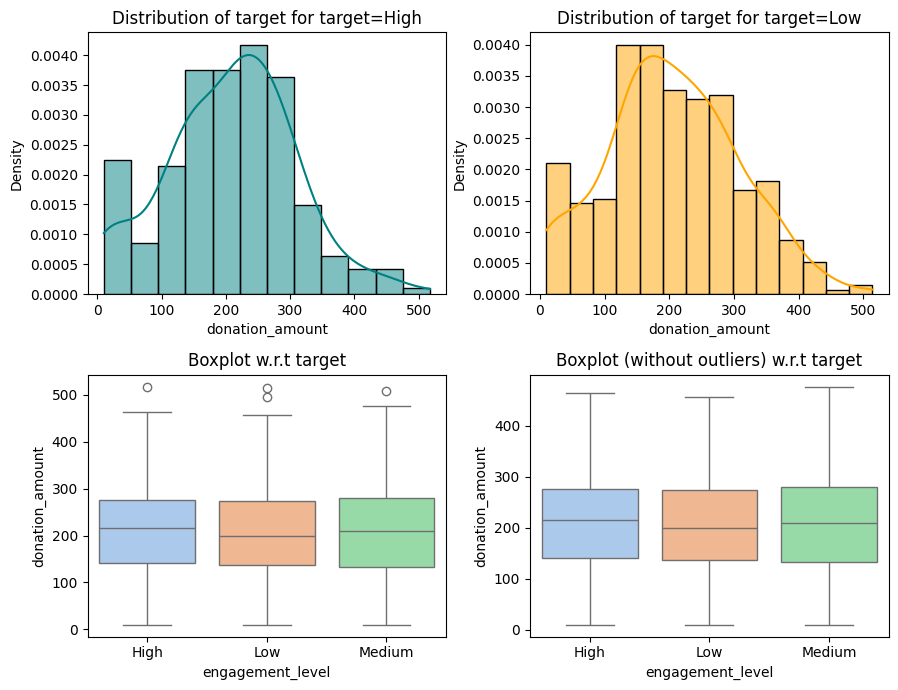

In [88]:
distribution_plot_wrt_target(df_donors, "donation_amount", "engagement_level")

<ipython-input-86-4171c9f0f443>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="pastel")
<ipython-input-86-4171c9f0f443>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


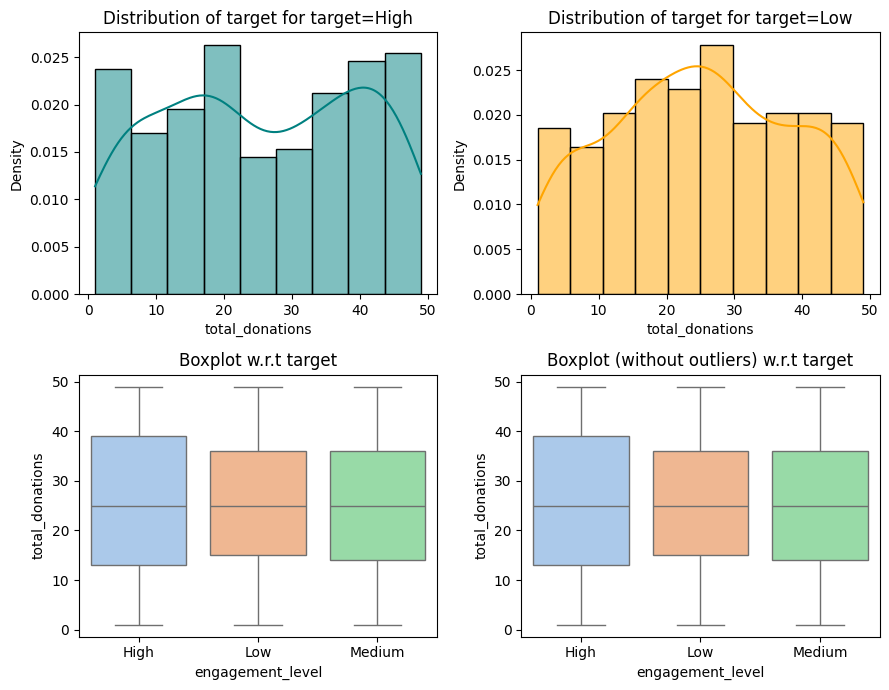

In [89]:
distribution_plot_wrt_target(df_donors, "total_donations", "engagement_level")

<ipython-input-86-4171c9f0f443>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="pastel")
<ipython-input-86-4171c9f0f443>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


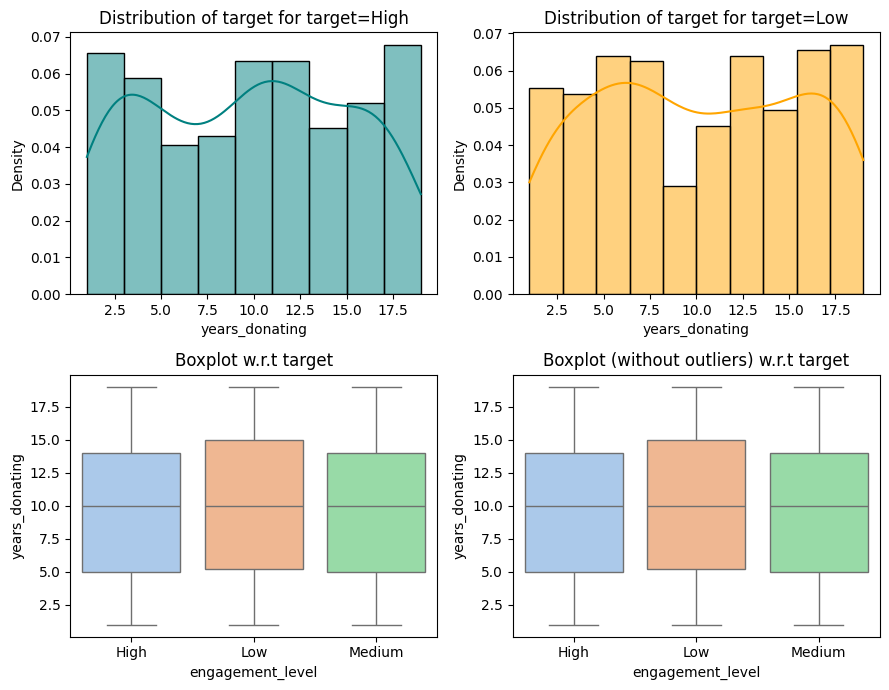

In [90]:
distribution_plot_wrt_target(df_donors, "years_donating", "engagement_level")

<ipython-input-86-4171c9f0f443>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="pastel")
<ipython-input-86-4171c9f0f443>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


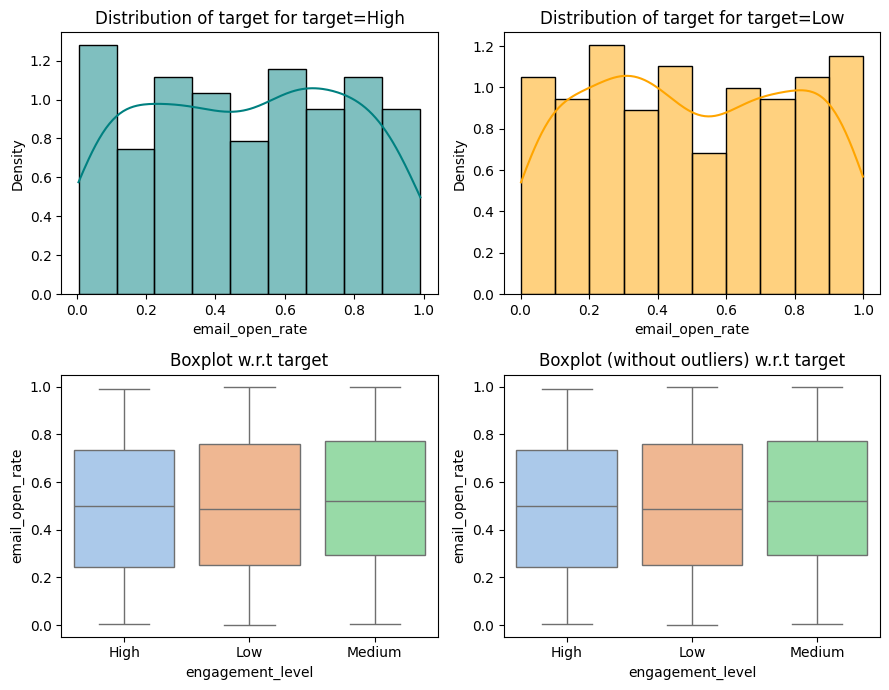

In [91]:
distribution_plot_wrt_target(df_donors, "email_open_rate", "engagement_level")

## visualization of synthetic data created

Donation Distribution (Histogram of donation amounts)

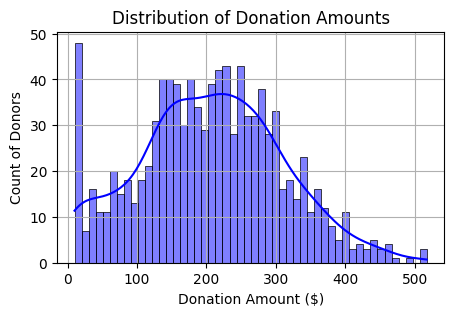

In [92]:
plt.figure(figsize=(5, 3))
sns.histplot(df_donors['donation_amount'], bins=50, kde=True, color='blue')
plt.title('Distribution of Donation Amounts')
plt.xlabel('Donation Amount ($)')
plt.ylabel('Count of Donors')
plt.grid(True)
plt.show()


The spread of donation amounts and the ability to spot outliers.

Engagement by Donation Frequency (Bar Chart)

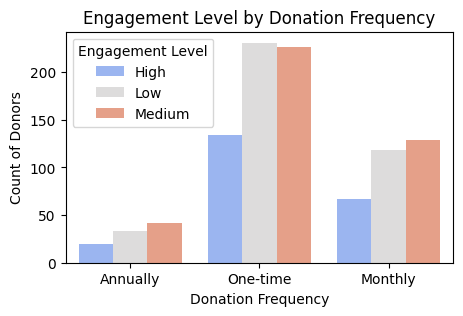

In [94]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df_donors, x='donation_frequency', hue='engagement_level', palette='coolwarm')
plt.title('Engagement Level by Donation Frequency')
plt.xlabel('Donation Frequency')
plt.ylabel('Count of Donors')
plt.legend(title='Engagement Level')
plt.show()

Number of donors by donation frequency

Preferred Payment Method Trends (Pie Chart)

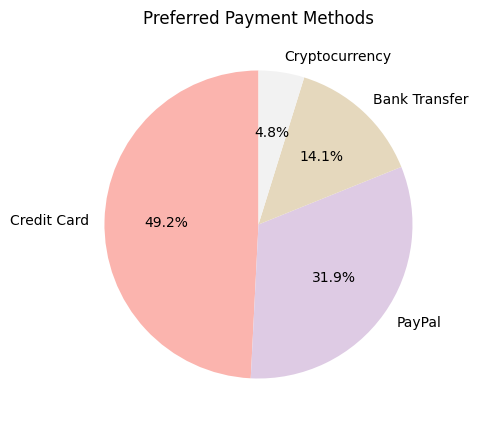

In [95]:
plt.figure(figsize=(5, 5))
df_donors['preferred_payment_method'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Pastel1', startangle=90)
plt.title('Preferred Payment Methods')
plt.ylabel('')
plt.show()


How payment methods compare.

Regional Donor Trends (Bar Chart)

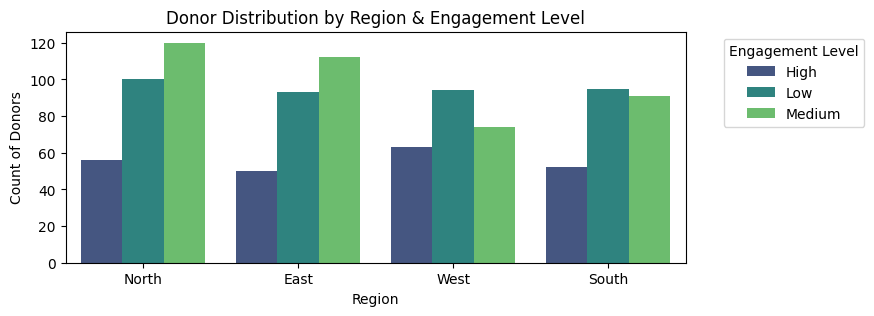

In [96]:
plt.figure(figsize=(8, 3))
sns.countplot(data=df_donors, x='region', palette='viridis', hue='engagement_level')
plt.title('Donor Distribution by Region & Engagement Level')
plt.xlabel('Region')
plt.ylabel('Count of Donors')
# Move the legend outside the plot
plt.legend(title='Engagement Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


How engagement varies by region.


# Feature Engineering


Some features to add:
* Total donations per donor over time
* Average donation amount per donor
* Years since first donation (seniority of donors)
* Donor retention (e.g., returning donors vs. one-time)
* Average Donation Per Year

In [97]:
# df_donors.info()

In [98]:
# Define number of donors and total donations
num_donors = 1000   # Unique donors
num_donations = 5000  # Total donation records

# Randomly assign donations to donors
donation_data = {
    'donor_id': np.random.choice(np.arange(1, num_donors + 1), num_donations),
    'donation_amount': np.random.normal(200, 100, num_donations).clip(10, 10000),  # Avg donation $200
    'donation_year': np.random.randint(2010, 2025, num_donations),  # Donations from 2010-2024
    'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer'], num_donations),
}

# Convert to DataFrame
df_donations = pd.DataFrame(donation_data)

# Sort by donor and year (for easier tracking)
df_donations = df_donations.sort_values(by=['donor_id', 'donation_year']).reset_index(drop=True)

# Check the first few rows
df_donations.head()


,donor_id,donation_amount,donation_year,payment_method
0,1,196.615241,2019,Credit Card
1,1,198.854411,2020,Bank Transfer
2,1,172.242769,2021,Credit Card
3,2,330.278328,2013,PayPal
4,2,382.840846,2013,Credit Card


In [99]:
df_donations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   donor_id         5000 non-null   int64  
 1   donation_amount  5000 non-null   float64
 2   donation_year    5000 non-null   int64  
 3   payment_method   5000 non-null   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 156.4+ KB


In [100]:
# Aggregate donation stats per donor
df_features = df_donations.groupby('donor_id').agg(
    total_donations=('donation_amount', 'sum'),
    avg_donation=('donation_amount', 'mean'),
    first_donation_year=('donation_year', 'min'),
    last_donation_year=('donation_year', 'max'),
    donation_count=('donation_amount', 'count'),
).reset_index()

# Calculate donor seniority and retention
df_features['donor_seniority'] = 2025 - df_features['first_donation_year']
df_features['donor_retention'] = df_features['donation_count'] > 1
df_features['avg_donation_per_year'] = df_features['total_donations'] / df_features['donor_seniority']

df_features.head()

,donor_id,total_donations,avg_donation,first_donation_year,last_donation_year,donation_count,donor_seniority,donor_retention,avg_donation_per_year
0,1,567.712421,189.237474,2019,2021,3,6,True,94.618737
1,2,713.119174,356.559587,2013,2013,2,12,True,59.426598
2,3,2062.101649,257.762706,2011,2017,8,14,True,147.292975
3,4,661.900969,220.633656,2010,2020,3,15,True,44.126731
4,5,833.721006,166.744201,2012,2024,5,13,True,64.132385


In [101]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   donor_id               995 non-null    int64  
 1   total_donations        995 non-null    float64
 2   avg_donation           995 non-null    float64
 3   first_donation_year    995 non-null    int64  
 4   last_donation_year     995 non-null    int64  
 5   donation_count         995 non-null    int64  
 6   donor_seniority        995 non-null    int64  
 7   donor_retention        995 non-null    bool   
 8   avg_donation_per_year  995 non-null    float64
dtypes: bool(1), float64(3), int64(5)
memory usage: 63.3 KB


In [102]:
# Merge back with df_donors and remove duplicate columns
df_donors = df_donors.merge(df_features, on='donor_id', how='left', suffixes=('', '_new'))

# Drop the old versions of duplicated columns
df_donors = df_donors.drop(columns=['total_donations', 'years_donating'], errors='ignore')

# Rename the new columns to remove "_new"
df_donors = df_donors.rename(columns=lambda x: x.replace('_new', ''))

# Fill NaN values (for donors with only one donation)
df_donors.fillna(0, inplace=True)

df_donors.head()

,donor_id,age,donation_amount,donation_frequency,region,donor_type,preferred_payment_method,engagement_level,email_open_rate,total_donations,avg_donation,first_donation_year,last_donation_year,donation_count,donor_seniority,donor_retention,avg_donation_per_year
0,1,56,337.237780,Annually,North,Individual,Credit Card,High,0.857917,567.712421,189.237474,2019.0,2021.0,3.0,6.0,True,94.618737
1,2,69,132.221391,One-time,East,Individual,Credit Card,Low,0.298548,713.119174,356.559587,2013.0,2013.0,2.0,12.0,True,59.426598
2,3,46,315.353187,Monthly,West,Corporate,PayPal,Medium,0.923743,2062.101649,257.762706,2011.0,2017.0,8.0,14.0,True,147.292975
3,4,32,162.498937,Monthly,North,Individual,PayPal,High,0.229806,661.900969,220.633656,2010.0,2020.0,3.0,15.0,True,44.126731
4,5,60,130.585405,One-time,North,Individual,Credit Card,Low,0.749516,833.721006,166.744201,2012.0,2024.0,5.0,13.0,True,64.132385


In [103]:
# Check the final DataFrame structure
df_donors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   donor_id                  1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   donation_amount           1000 non-null   float64
 3   donation_frequency        1000 non-null   object 
 4   region                    1000 non-null   object 
 5   donor_type                1000 non-null   object 
 6   preferred_payment_method  1000 non-null   object 
 7   engagement_level          1000 non-null   object 
 8   email_open_rate           1000 non-null   float64
 9   total_donations           1000 non-null   float64
 10  avg_donation              1000 non-null   float64
 11  first_donation_year       1000 non-null   float64
 12  last_donation_year        1000 non-null   float64
 13  donation_count            1000 non-null   float64
 14  donor_sen

 Keeps all original donor attributes (age, region, donor type, engagement level, etc.)

✔ Adds new columns (total donations, avg donation, years donating, retention, avg donation per year)

✔ Ensures every donor has all their features in one place

Total Donations Over Time

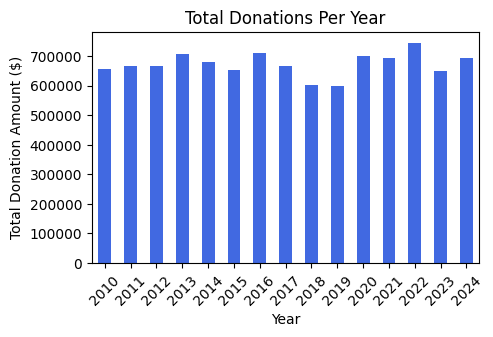

In [104]:
plt.figure(figsize=(5, 3))
df_donations.groupby('donation_year')['donation_year'].sum().plot(kind='bar', color='royalblue')
plt.title('Total Donations Per Year')
plt.xlabel('Year')
plt.ylabel('Total Donation Amount ($)')
plt.xticks(rotation=45)
plt.show()


Distribution of Average Donation Amounts

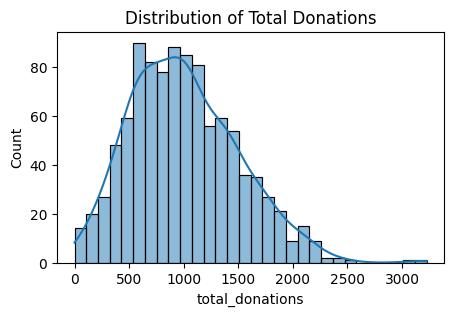

In [105]:
plt.figure(figsize=(5, 3))
sns.histplot(df_donors['total_donations'], bins=30, kde=True)
plt.title("Distribution of Total Donations")
plt.show()


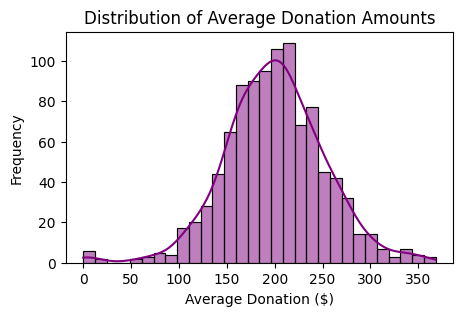

In [106]:
plt.figure(figsize=(5, 3))
sns.histplot(df_donors['avg_donation'], bins=30, kde=True, color='purple')
plt.title('Distribution of Average Donation Amounts')
plt.xlabel('Average Donation ($)')
plt.ylabel('Frequency')
plt.show()


Donor Seniority vs. Total Donations

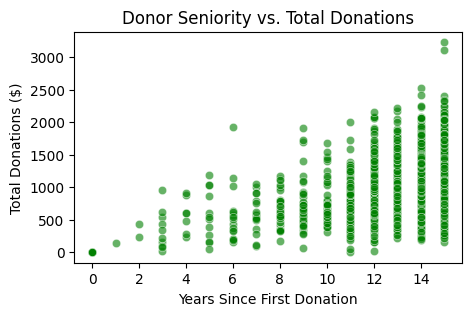

In [107]:
plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_donors, x='donor_seniority', y='total_donations', alpha=0.6, color='green')
plt.title('Donor Seniority vs. Total Donations')
plt.xlabel('Years Since First Donation')
plt.ylabel('Total Donations ($)')
plt.show()


Returning vs. One-Time Donors

<ipython-input-108-bfe19699093a>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_donors, x='donor_retention', palette='coolwarm')


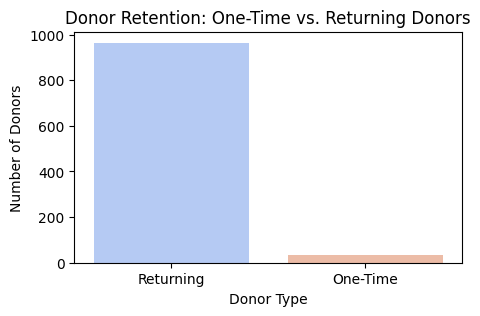

In [108]:
# Replace True/False with 'Returning'/'One-Time'
df_donors['donor_retention'] = df_donors['donor_retention'].map({True: 'Returning', False: 'One-Time'})

# Plot updated countplot
plt.figure(figsize=(5, 3))
sns.countplot(data=df_donors, x='donor_retention', palette='coolwarm')
plt.title('Donor Retention: One-Time vs. Returning Donors')
plt.xlabel('Donor Type')
plt.ylabel('Number of Donors')
plt.show()


Average Donation Per Year

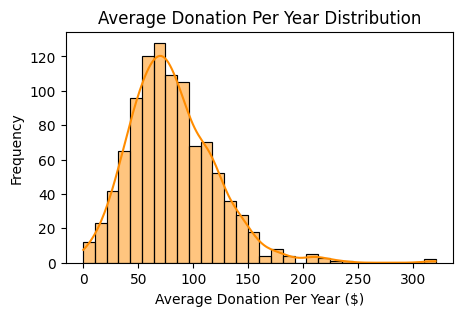

In [109]:
plt.figure(figsize=(5, 3))
sns.histplot(df_donors['avg_donation_per_year'], bins=30, kde=True, color='darkorange')
plt.title('Average Donation Per Year Distribution')
plt.xlabel('Average Donation Per Year ($)')
plt.ylabel('Frequency')
plt.show()


#### See how donor_seniority, avg_donation_per_year, and donor_retention interact

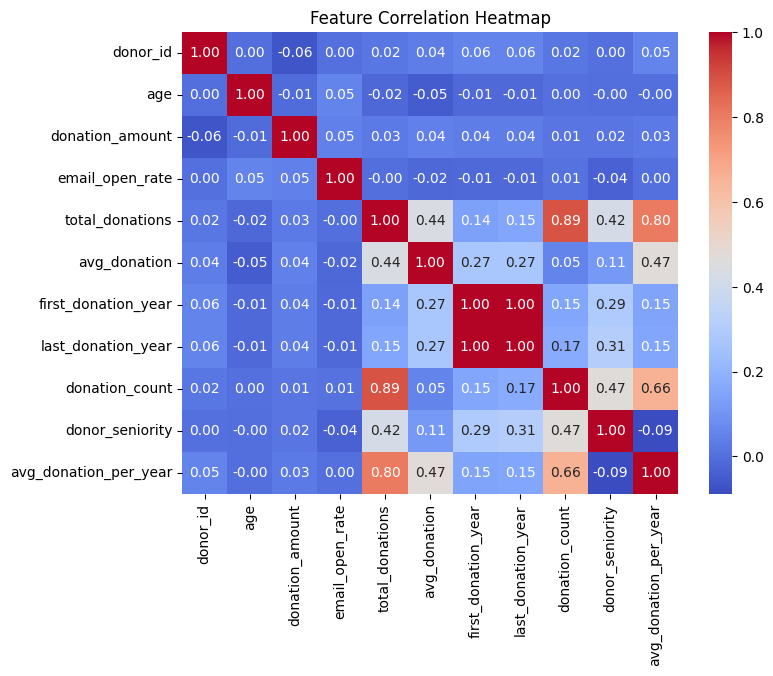

In [110]:
# Select only numeric columns
numeric_cols = df_donors.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


Visualizations to see which donor groups are most engaged


<ipython-input-111-416e2e23074e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_donors, x='donor_retention', y='email_open_rate', palette='coolwarm')


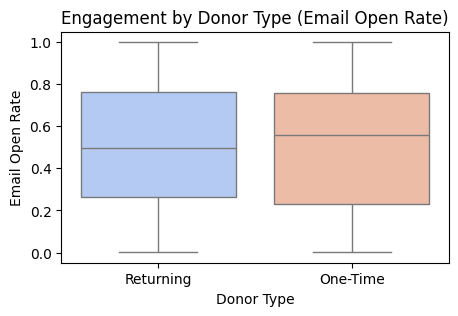

In [111]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_donors, x='donor_retention', y='email_open_rate', palette='coolwarm')
plt.title('Engagement by Donor Type (Email Open Rate)')
plt.xlabel('Donor Type')
plt.ylabel('Email Open Rate')
plt.show()


Who Gives More? Donation Amount by Donor Type

<ipython-input-112-eb6b45d22cfa>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_donors, x='donor_retention', y='donation_amount', palette='coolwarm')


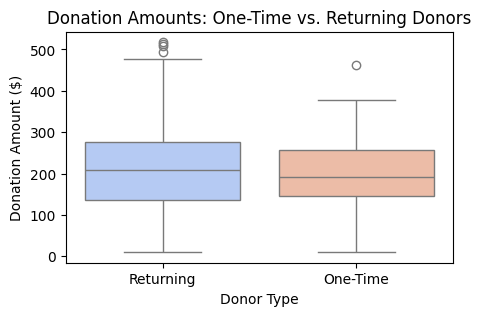

In [112]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_donors, x='donor_retention', y='donation_amount', palette='coolwarm')
plt.title('Donation Amounts: One-Time vs. Returning Donors')
plt.xlabel('Donor Type')
plt.ylabel('Donation Amount ($)')
plt.show()


Who Gives the Most? Total Donations by Age Group

<ipython-input-114-4f5fcc8acd07>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_donors, x='age_group', y='total_donations', palette='magma', estimator=np.mean)


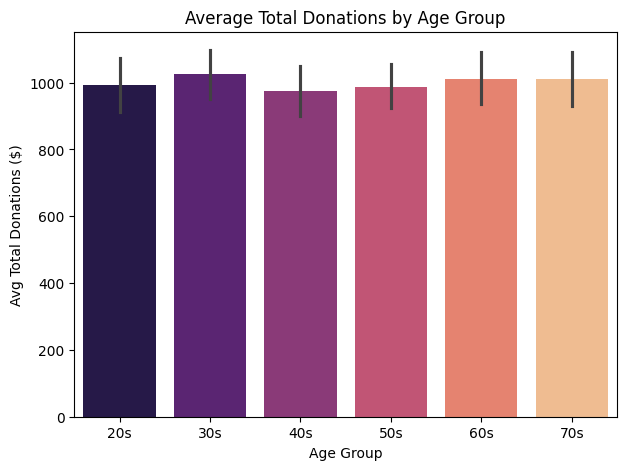

In [114]:
df_donors['age_group'] = pd.cut(df_donors['age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20s', '30s', '40s', '50s', '60s', '70s'])
plt.figure(figsize=(7, 5))
sns.barplot(data=df_donors, x='age_group', y='total_donations', palette='magma', estimator=np.mean)
plt.title('Average Total Donations by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Avg Total Donations ($)')
plt.show()


Which Payment Method is Most Popular Among Donors?

<ipython-input-115-2c576b19d8c0>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_donors, x='preferred_payment_method', palette='pastel')


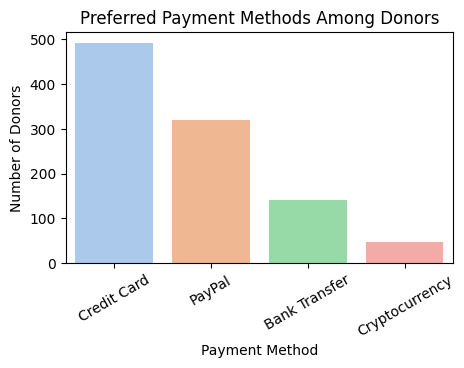

In [115]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df_donors, x='preferred_payment_method', palette='pastel')
plt.title('Preferred Payment Methods Among Donors')
plt.xlabel('Payment Method')
plt.ylabel('Number of Donors')
plt.xticks(rotation=30)
plt.show()


What Regions Are Most Generous?

<ipython-input-116-c0ee7d41e194>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_donors, x='region', y='total_donations', palette='viridis', estimator=np.mean)


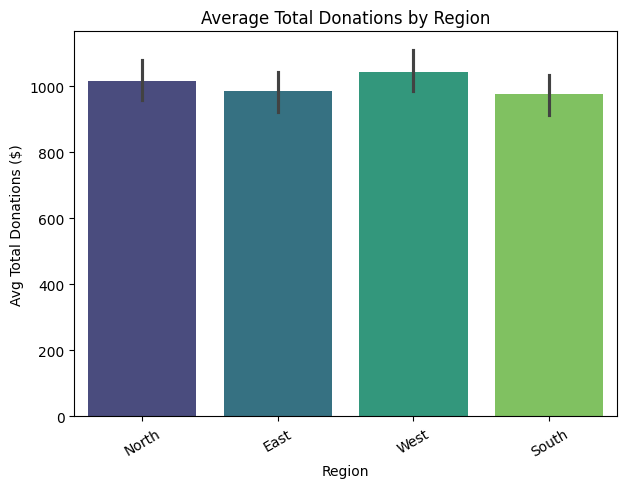

In [116]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df_donors, x='region', y='total_donations', palette='viridis', estimator=np.mean)
plt.title('Average Total Donations by Region')
plt.xlabel('Region')
plt.ylabel('Avg Total Donations ($)')
plt.xticks(rotation=30)
plt.show()


 How Do Donations Grow Over Time? (Time-Series Plot)

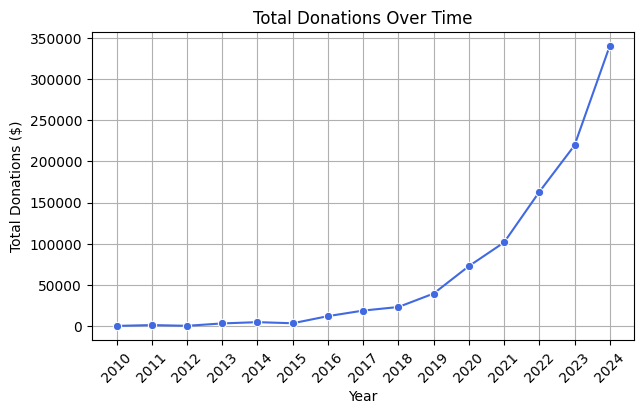

In [117]:
# Filter out unrealistic years (e.g., assuming donations started in 2000)
donation_trends = df_donors[df_donors['last_donation_year'] >= 2000]

# Aggregate total donations by year
donation_trends = donation_trends.groupby('last_donation_year')['total_donations'].sum().reset_index()

plt.figure(figsize=(7, 4))
sns.lineplot(data=donation_trends, x='last_donation_year', y='total_donations', marker='o', color='royalblue')

plt.title('Total Donations Over Time')
plt.xlabel('Year')
plt.ylabel('Total Donations ($)')
plt.xticks(donation_trends['last_donation_year'].astype(int), rotation=45)  # Rotate x-axis labels

plt.grid(True)
plt.show()


Showing strong growth in donations over time.

# Segmentation (Clustering)

With Google Gemini collaboration

1. Data Preparation:

First, we need to prepare the data for clustering. We'll select the relevant columns and scale them to ensure that features with larger ranges don't dominate the clustering process.

2.  Reduce columns

Here's a breakdown of why and when you should limit the number of columns used in clustering:

Reasons for Limiting Columns:

Curse of Dimensionality:

As the number of dimensions (columns) increases, the data becomes increasingly sparse.
In high-dimensional spaces, distances between data points become less meaningful, making clustering less effective.
This is especially true for distance-based algorithms like K-Means.
Noise and Irrelevant Features:

Including irrelevant or noisy features can obscure the underlying patterns in the data and lead to poor clustering results.
Clustering algorithms are sensitive to noise, and irrelevant features can introduce noise.
Interpretability:

Clustering results are easier to interpret and visualize when you use a smaller number of relevant features.
Visualizing clusters in high-dimensional spaces is challenging.
Computational Efficiency:

Clustering algorithms can be computationally expensive, especially for large datasets with many features.
Reducing the number of features can significantly improve performance.
When to Include More Columns:

Strong Domain Knowledge: If you have strong domain knowledge and know that certain features are highly relevant to the clustering task, you can include them.
Feature Selection Techniques: You can use feature selection techniques (e.g., principal component analysis (PCA), feature importance from tree-based models) to identify the most informative features and include them in the clustering.
Dimensionality Reduction: Techniques like PCA can reduce the dimensionality of your data while preserving most of the variance.
In the Donor Segmentation Example:

We focused on total_donations, donation_frequency, and engagement_level because they are likely to be strong indicators of donor behavior and value.
These features are also very relevant to the business questions.
We wanted to keep the results relatively simple to view and understand.
We converted the categorical columns to numerical data, as K-means requires numerical data.
Recommendations:

Always carefully consider which features are most relevant to your clustering task.
Use feature selection or dimensionality reduction techniques when dealing with high-dimensional data.
Prioritize interpretability and visualization when choosing features.

In [118]:
# # Drop the 'donor_id' column
# df_donors = df_donors.drop('donor_id', axis=1)

# Select relevant columns for clustering
clustering_data = df_donors[['total_donations', 'donation_frequency', 'engagement_level']]

# Convert categorical 'donation_frequency' and 'engagement_level' to numerical using one-hot encoding
clustering_data = pd.get_dummies(clustering_data, columns=['donation_frequency', 'engagement_level'])

# Scale the numerical features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(clustering_data)

# Convert scaled data back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=clustering_data.columns)

# verify
scaled_df.head()

### refinements
# elbow meoth n=7 with:
#StandardScaler() --> Silhouette Score: 0.6291095052101964
#MinMaxScaler: Scales the data to a fixed range, typically
#between 0 and 1. It's sensitive to outliers.
        #MinMaxScaler, --> Silhouette Score: 0.8253816761927225
#RobustScaler: Scales the data using percentiles, making it more robust to outliers.
#It centers the data around the median and scales it based on the interquartile range (IQR)
#RobustScaler --> 0.42319709584642523
     #n = 8 Silhouette Score: 0.8574313460139256
    # n= 6 Silhouette Score: 0.7467203831230258
   # n=10 Silhouette Score: 0.8393019008085437
   # n=9 Silhouette Score: 0.8796795605924868

,total_donations,donation_frequency_Annually,donation_frequency_Monthly,donation_frequency_One-time,engagement_level_High,engagement_level_Low,engagement_level_Medium
0,0.175944,1.0,0.0,0.0,1.0,0.0,0.0
1,0.221008,0.0,0.0,1.0,0.0,1.0,0.0
2,0.639082,0.0,1.0,0.0,0.0,0.0,1.0
3,0.205135,0.0,1.0,0.0,1.0,0.0,0.0
4,0.258385,0.0,0.0,1.0,0.0,1.0,0.0


Why Drop donor_id?

Unique Identifiers: donor_id is a unique identifier for each donor. It doesn't provide any information about the donor's donation behavior or characteristics.

Noise: Including donor_id in the clustering process can introduce noise and obscure the underlying patterns in the data.

Bias: K-Means clustering is sensitive to the scale of features. Including donor_id (which is typically a large integer) can bias the clustering towards this feature.

Meaningless Clusters: Clusters based on donor_id would be meaningless, as they would simply group donors based on their unique IDs.


In [119]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=7, random_state=42)  # Adjust n_clusters as needed
df_donors['cluster'] = kmeans.fit_predict(scaled_df)

In [120]:
# verify
df_donors.head()

,donor_id,age,donation_amount,donation_frequency,region,donor_type,preferred_payment_method,engagement_level,email_open_rate,total_donations,avg_donation,first_donation_year,last_donation_year,donation_count,donor_seniority,donor_retention,avg_donation_per_year,age_group,cluster
0,1,56,337.237780,Annually,North,Individual,Credit Card,High,0.857917,567.712421,189.237474,2019.0,2021.0,3.0,6.0,Returning,94.618737,50s,4
1,2,69,132.221391,One-time,East,Individual,Credit Card,Low,0.298548,713.119174,356.559587,2013.0,2013.0,2.0,12.0,Returning,59.426598,60s,3
2,3,46,315.353187,Monthly,West,Corporate,PayPal,Medium,0.923743,2062.101649,257.762706,2011.0,2017.0,8.0,14.0,Returning,147.292975,40s,2
3,4,32,162.498937,Monthly,North,Individual,PayPal,High,0.229806,661.900969,220.633656,2010.0,2020.0,3.0,15.0,Returning,44.126731,30s,6
4,5,60,130.585405,One-time,North,Individual,Credit Card,Low,0.749516,833.721006,166.744201,2012.0,2024.0,5.0,13.0,Returning,64.132385,50s,3


In [121]:
print(df_donors.columns)

Index(['donor_id', 'age', 'donation_amount', 'donation_frequency', 'region',
       'donor_type', 'preferred_payment_method', 'engagement_level',
       'email_open_rate', 'total_donations', 'avg_donation',
       'first_donation_year', 'last_donation_year', 'donation_count',
       'donor_seniority', 'donor_retention', 'avg_donation_per_year',
       'age_group', 'cluster'],
      dtype='object')


3.  Cluster Visualization:



We'll create a scatter plot to visualize the clusters based on two key features: 'total_donations' and 'donation_frequency'.

Scatter Plots: Create scatter plots of your data points, colored by their cluster assignments. This helps you visually assess the separation and compactness of the clusters.
Example: sns.scatterplot(x='total_donations', y='donation_frequency_Monthly', hue='cluster', data=df_donors, palette='viridis')

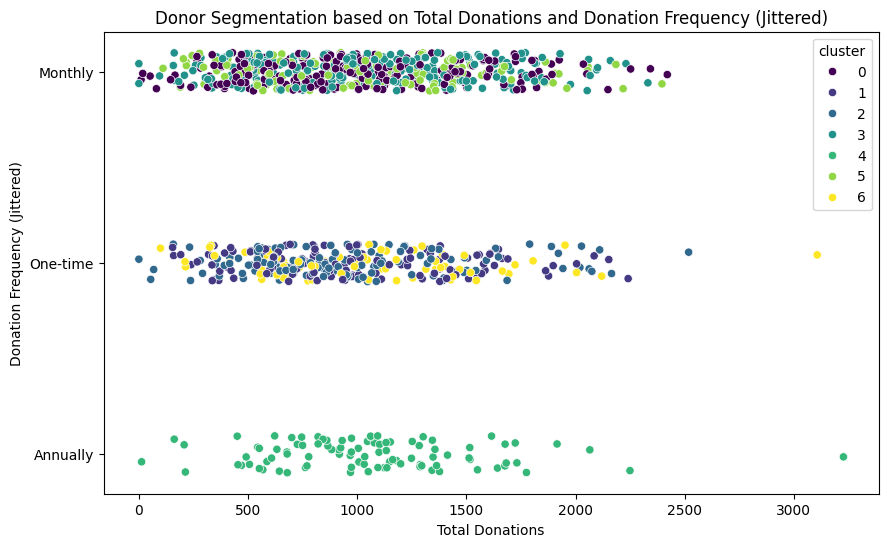

In [122]:
# Add jitter to the 'donation_frequency' column
jitter = 0.1  # Adjust jitter amount as needed
df_donors['donation_frequency_jittered'] = pd.Categorical(df_donors['donation_frequency']).codes + np.random.uniform(-jitter, jitter, size=len(df_donors))

# Visualize clusters with jitter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_donations', y='donation_frequency_jittered', hue='cluster', data=df_donors, palette='viridis')
plt.title('Donor Segmentation based on Total Donations and Donation Frequency (Jittered)')
plt.xlabel('Total Donations')
plt.ylabel('Donation Frequency (Jittered)')

# Corrected yticks:
unique_codes = np.unique(pd.Categorical(df_donors['donation_frequency']).codes) #use np.unique
unique_labels = df_donors['donation_frequency'].unique()
plt.yticks(ticks=unique_codes, labels=unique_labels)

plt.show()

X-axis (Total Donations):
* Represents the total amount of money donated by each donor.
* Donors on the right side of the plot have made larger total donations.

Y-axis (Donation Frequency (Jittered)):
* Represents the frequency of donations, but with added jitter. The jitter helps to spread out the points within each category, making it easier to see the distribution.
* "Monthly" is at the top, "One-time" in the middle, and "Annually" at the bottom.

Hue (Cluster):
* The color of each point represents the cluster to which that donor has been assigned by the K-Means algorithm.
* The legend on the right shows which color corresponds to which cluster.


* Key Observations:
  * There are a number of high value one time doners.
  * Monthly doners tend to be in the lower total donation amounts.
  * Annually doners tend to vary widely in total donation amount.


 Box Plots or Violin Plots:

 Instead of a scatter plot, we can use box plots or violin plots to show the distribution of "Total Donations" within each "Donation Frequency" category, separated by cluster.

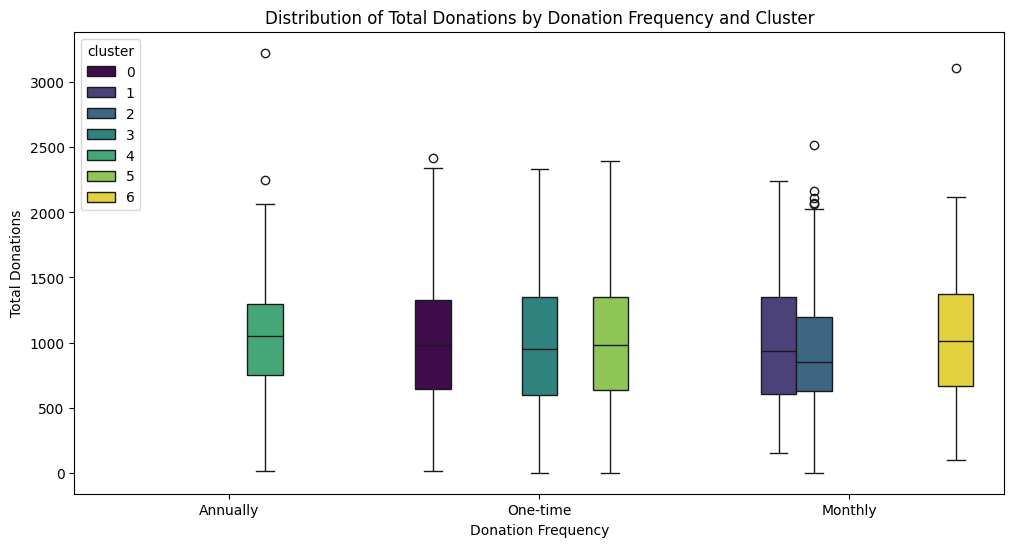

In [ ]:
# Box plots
plt.figure(figsize=(12, 6))
sns.boxplot(x='donation_frequency', y='total_donations', hue='cluster', data=df_donors, palette='viridis')
plt.title('Distribution of Total Donations by Donation Frequency and Cluster')
plt.xlabel('Donation Frequency')
plt.ylabel('Total Donations')
plt.show()



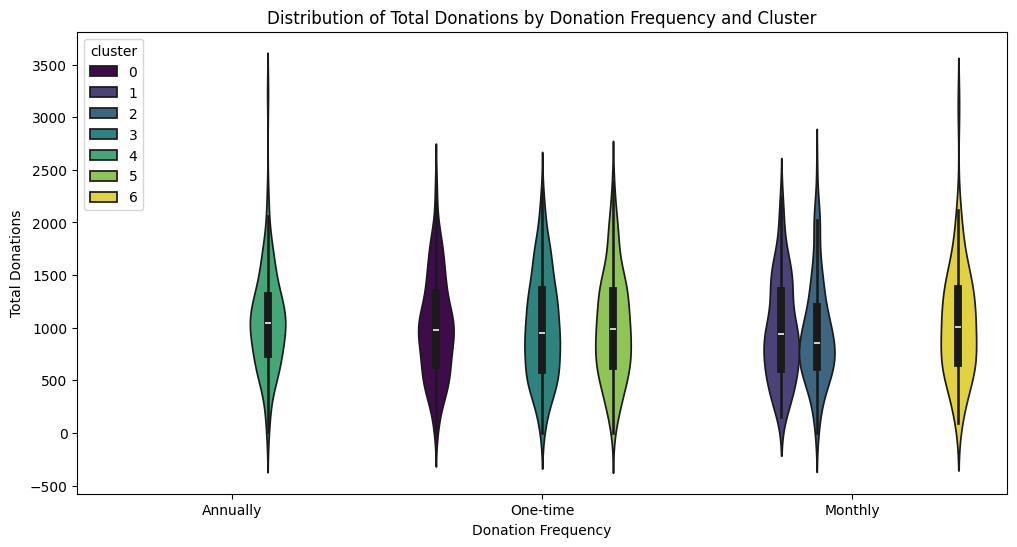

In [123]:
# Violin plots
plt.figure(figsize=(12, 6))
sns.violinplot(x='donation_frequency', y='total_donations', hue='cluster', data=df_donors, palette='viridis')
plt.title('Distribution of Total Donations by Donation Frequency and Cluster')
plt.xlabel('Donation Frequency')
plt.ylabel('Total Donations')
plt.show()

 Bar Charts

 If you want to see the average "Total Donations" for each "Donation Frequency" category, grouped by cluster, you can use bar charts.

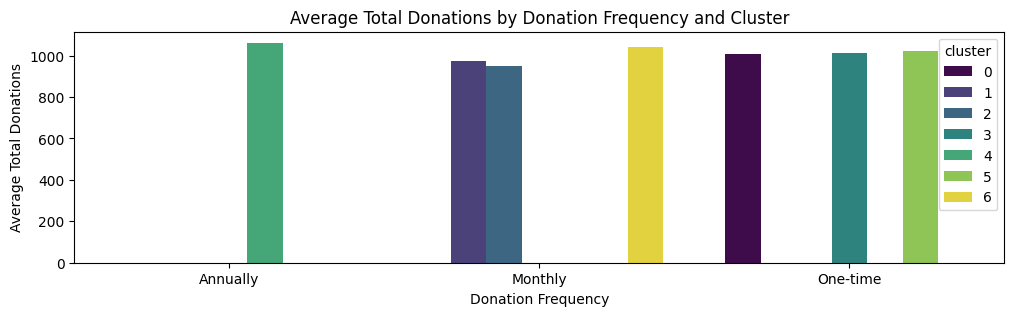

In [124]:
# Bar charts
df_grouped = df_donors.groupby(['donation_frequency', 'cluster'])['total_donations'].mean().reset_index()

plt.figure(figsize=(12, 3))
sns.barplot(x='donation_frequency', y='total_donations', hue='cluster', data=df_grouped, palette='viridis')
plt.title('Average Total Donations by Donation Frequency and Cluster')
plt.xlabel('Donation Frequency')
plt.ylabel('Average Total Donations')
plt.show()

#### Pair Plots:  use pair plots to visualize all pairwise relationships between features, colored by cluster assignments.


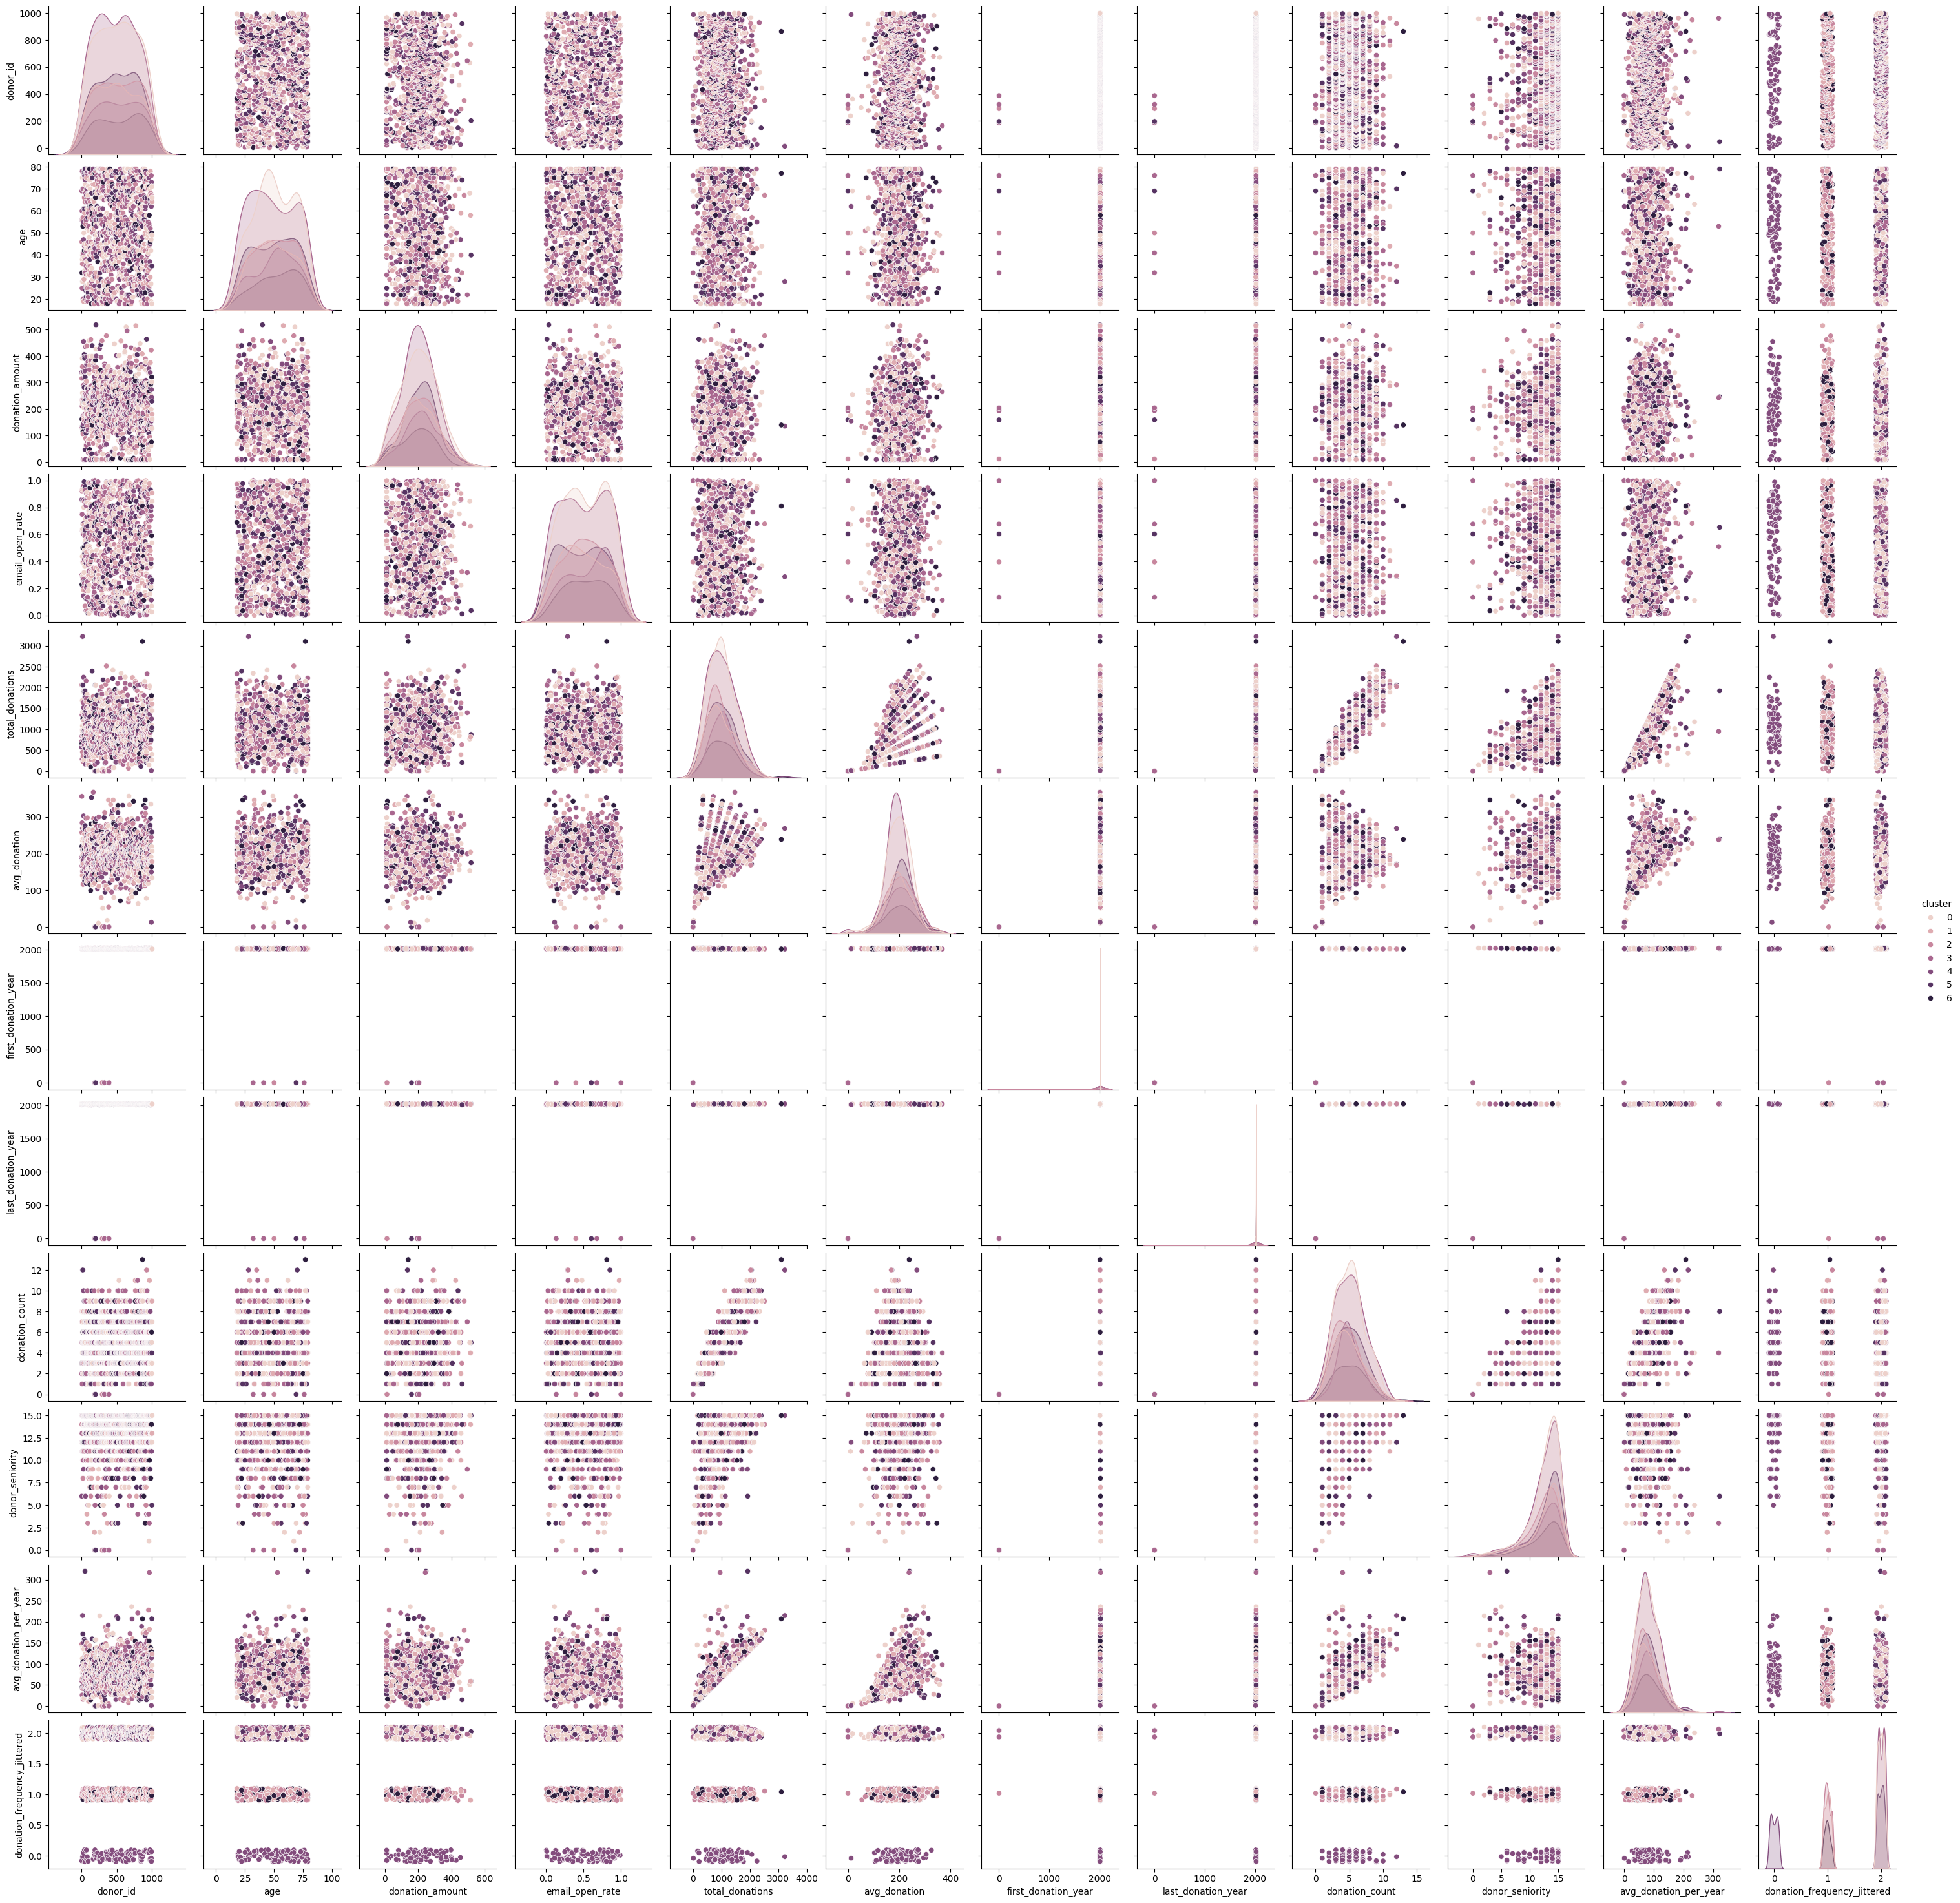

In [125]:
# Create the pair plot
sns.pairplot(df_donors, hue='cluster')

# Show the plot
plt.show()

hue='cluster': Colors the points in the plots based on the 'cluster' column.

Pair plots can become computationally expensive and difficult to interpret with a large number of features. If your df_donors DataFrame has many columns, consider selecting only the most relevant ones for the pair plot. For example:

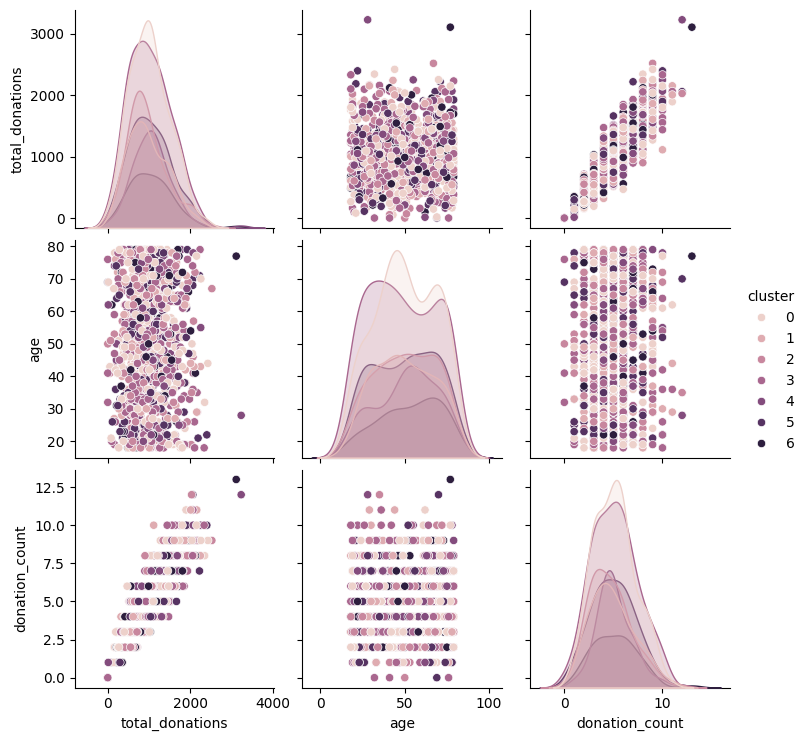

In [126]:
relevant_columns = ['total_donations', 'age', 'donation_count', 'cluster']  # Select relevant columns
sns.pairplot(df_donors[relevant_columns], hue='cluster')
plt.show()

The pairplot will show every numerical column plotted against every other numerical column, and it will color each dot by the cluster label.

If you have categorical columns in your data frame, they will be ignored by the pair plot.

### Cluster Statistics:

Cluster Size: Check the number of data points in each cluster. Uneven cluster sizes might indicate issues.
Example: df_donors['cluster'].value_counts()

In [127]:
# Calculate and display the cluster sizes
cluster_sizes = df_donors['cluster'].value_counts()
print("Cluster Sizes:")
print(cluster_sizes)

Cluster Sizes:
cluster
3    231
0    226
5    134
2    129
1    118
4     95
6     67
Name: count, dtype: int64


####Cluster Centroids:
* Examine the cluster centroids (the **mean/average values of each feature within each cluster**). This helps you understand the characteristics of each cluster.


* Exclude the Non-Numeric Column

In [128]:
# Select only numeric columns for centroid calculation
numeric_cols = df_donors.select_dtypes(include=['number']).columns.tolist()

# Ensure 'cluster' is included
if 'cluster' not in numeric_cols:
    numeric_cols.append('cluster')

# Calculate and display the cluster centroids using only numeric columns
cluster_centroids = df_donors[numeric_cols].groupby('cluster').mean()
print("Cluster Centroids (Numeric Columns Only):")
cluster_centroids

Cluster Centroids (Numeric Columns Only):


,donor_id,age,donation_amount,email_open_rate,total_donations,avg_donation,first_donation_year,last_donation_year,donation_count,donor_seniority,avg_donation_per_year,donation_frequency_jittered
cluster,,,,,,,,,,,,
0,502.088496,50.137168,205.043710,0.517321,1006.059451,195.767151,2012.433628,2021.712389,5.066372,12.566372,80.667481,1.997488
1,490.703390,49.661017,211.020059,0.490368,973.969416,200.574834,2012.364407,2021.898305,4.915254,12.635593,79.114589,0.999265
2,513.201550,49.906977,205.755077,0.506377,950.178723,203.027347,1997.232558,2006.000000,4.643411,12.069767,79.564970,1.000056
3,480.290043,48.272727,201.177713,0.504341,1010.033155,194.921222,1986.238095,1995.463203,5.108225,12.463203,80.597215,2.005849
4,515.431579,51.105263,221.644045,0.551802,1062.045843,203.937590,2012.505263,2021.705263,5.126316,12.494737,86.786208,-0.000242
5,499.194030,49.888060,211.360015,0.471265,1020.356859,205.828161,1997.149254,2006.216418,4.970149,12.738806,81.606960,1.998401
6,539.059701,52.791045,187.865655,0.527766,1041.131303,205.923160,2012.567164,2021.925373,5.119403,12.432836,84.255695,0.992720


Interpreting the Output:

* The output will show you the mean values of each feature for each cluster. For example:

* What to Look For:

  * Distinct Characteristics: Look for differences in the mean values across the clusters. This helps you understand the unique characteristics of each group.

  * Feature Importance: The cluster centroids can give you an idea of which features are most important in distinguishing the clusters.



* Actionable Insights:

  * Use the cluster profiles to develop targeted fundraising and engagement strategies for each group.

These insights can help you tailor your fundraising efforts to each cluster.



Descriptive Statistics: Calculate descriptive statistics (mean, median, standard deviation) for each feature within each cluster.

In [129]:
# Calculate descriptive statistics for each feature within each cluster
cluster_stats = df_donors.groupby('cluster').describe().T

# Print the descriptive statistics
cluster_stats

cluster                                     0           1           2  \
donor_id                    count  226.000000  118.000000  129.000000   
                            mean   502.088496  490.703390  513.201550   
                            std    290.383044  286.524064  295.024665   
                            min      8.000000    9.000000    3.000000   
                            25%    258.500000  241.250000  275.000000   
...                                       ...         ...         ...   
donation_frequency_jittered min      1.900218    0.903718    0.902888   
                            25%      1.948514    0.951835    0.956454   
                            50%      1.997166    0.998486    0.992432   
                            75%      2.042166    1.043451    1.050787   
                            max      2.099759    1.097650    1.098874   

cluster                                     3           4           5  \
donor_id                    count  231.000000   95.000000  134.000000   
                            mean   480.290043  515.431579  499.194030   
                            std    282.153547  301.661063  280.351377   
                            min      2.000000    1.000000   16.000000   
                            25%    237.000000  255.500000  254.000000   
...                                       ...         ...         ...   
donation_frequency_jittered min      1.901138   -0.096627    1.900341   
                            25%      1.953924   -0.056528    1.946886   
                            50%      2.006262   -0.004489    1.998071   
                            75%      2.056784    0.053334    2.045252   
                            max      2.099591    0.096020    2.099501   

cluster                                     6  
donor_id                    count   67.000000  
                            mean   539.059701  
                            std    302.729296  
                            min      4.000000  
                            25%    257.000000  
...                                       ...  
donation_frequency_jittered min      0.906839  
                            25%      0.949940  
                            50%      0.985695  
                            75%      1.030351  
                            max      1.095888  

[96 rows x 7 columns]

### Evaluation Metrics:

Silhouette Score: Measures how similar each data point is to its own cluster compared to other clusters. Higher scores indicate better clustering.

In [130]:
# metric
silhouette_avg = silhouette_score(scaled_df, df_donors['cluster'])
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.8253816761927225


Understanding the Silhouette Score:
* Range: The Silhouette Score ranges from -1 to 1.

Interpretation:
* 1: Indicates that data points are well-clustered, with high similarity to their own cluster and low similarity to other clusters.
* 0: Indicates overlapping clusters or data points that are close to the decision boundary between clusters.
* -1: Indicates that data points may be assigned to the wrong clusters.


#### with n = 7 Clusters

Silhouette Score = 0.825

which is excellent:

Strong Cluster Separation: A Silhouette Score this high indicates very well-defined and separated clusters.

High Confidence: You can have a high degree of confidence in the validity and usefulness of your clustering results.

Meaningful Insights: The clusters you've identified are likely to represent distinct and meaningful groups of donors.

Actionable Results: The improved clustering provides even more actionable insights for your fundraising efforts.

#### Elbow method to determine number of clusters

Within-Cluster Sum of Squares (WCSS): Used in the elbow method to determine the optimal number of clusters. Lower WCSS indicates tighter clusters.

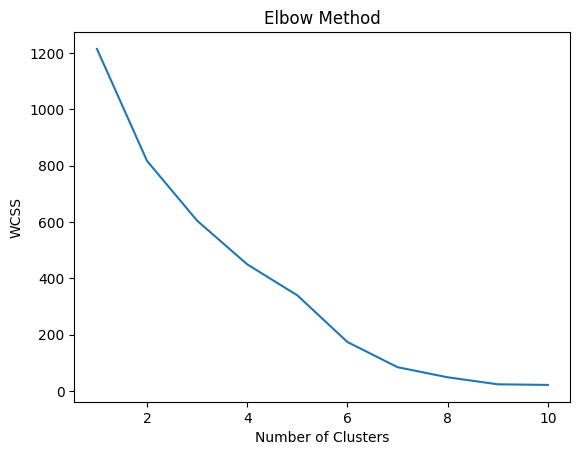

In [131]:
# Assuming df_donors is your DataFrame and scaled_df is your scaled DataFrame

# Calculate WCSS for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the elbow method
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

Calculate WCSS:
* We iterate through different numbers of clusters (from 1 to 10 in this example).
* For each number of clusters, we:
  * Create a KMeans object with the specified number of clusters and a fixed random_state for reproducibility.
  * Fit the K-Means model to the scaled data (scaled_df).
  * Append the inertia_ attribute of the fitted model to the wcss list. The inertia_ attribute represents the WCSS.

* Plot the Elbow Method:
  * We plot the wcss values against the number of clusters.
  * The resulting plot shows how the WCSS decreases as the number of clusters increases.

* Interpreting the Elbow Plot:
  * Elbow Point: Look for the "elbow" point in the plot, where the rate of decrease in WCSS starts to slow down. This point is considered the optimal number of clusters.

* Rationale:
  * The elbow point represents the point where adding more clusters doesn't significantly reduce the WCSS, indicating that the clusters are becoming less compact.
  * Example: If the plot shows a sharp decrease in WCSS up to 3 clusters, and then the rate of decrease slows down, you might choose 3 as the optimal number of clusters.

* Important Notes:
  * Scaled Data: It's crucial to use the scaled data (scaled_df) for K-Means clustering.
  * Number of Clusters Range: You can adjust the range of clusters (1 to 11 in this example) based on your data and expectations.
   Elbow Point Ambiguity: In some cases, the elbow point might not be very clear. In such situations, you can use other evaluation metrics like the Silhouette Score to help you choose the optimal number of clusters.

The elbow method suggests that the "bend" or "elbow" is at 7 clusters, then re-running the analysis with n_clusters=7 is the correct approach.


Steps After Finding the Elbow Point:

* Modify your K-Means code to use n_clusters=7.
* Re-run the clustering algorithm and assign the new cluster labels to your DataFrame.

## Analysis of Cluster Centroids (n=7):

* Cluster 0:

Moderate age, moderate donation amount, moderate email open rate, moderate total donations, moderate avg donation, moderate donation count, moderate donor seniority, and moderate avg donation per year.

Appears to be a general, average donor group.

* Cluster 1:

Moderate age, higher donation amount, moderate email open rate, higher total donations, higher avg donation, moderate donation count, moderate donor seniority, and moderate avg donation per year.

High value donor group.

* Cluster 2:

Moderate age, lower donation amount, moderate email open rate, lower total donations, lower avg donation, moderate donation count, moderate donor seniority, and moderate avg donation per year.

Low value donor group.

* Cluster 3:

Moderate age, moderate donation amount, moderate email open rate, moderate total donations, moderate avg donation, moderate donation count, moderate donor seniority, and moderate avg donation per year.

Appears to be a general, average donor group.

* Cluster 4:

Moderate age, higher donation amount, higher email open rate, Higher total donations, higher avg donation, moderate donation count, moderate donor seniority, and higher avg donation per year.

This group is very similar to cluster 1, but with a higher email open rate, and higher avg donation per year.

* Cluster 5:

Moderate age, lower donation amount, moderate email open rate, lower total donations, lower avg donation, moderate donation count, moderate donor seniority, and moderate avg donation per year.

This group is very similar to cluster 2.

* Cluster 6:

Moderate age, moderate donation amount, moderate email open rate, moderate total donations, moderate avg donation, moderate donation count, moderate donor seniority, and moderate avg donation per year.

This group is very similar to clusters 0 and 3.

## Salient Differences and Recommendations:

* Actionable Groups:

The 7 clusters provide a good balance between granularity and practicality. You can create distinct profiles and strategies for each of these groups.

High-Value vs. Low-Value:

Clusters 1 and 4 represent high-value donors, while clusters 2 and 5 represent low-value donors. This is a crucial distinction for fundraising.

Average Donors:

Clusters 0, 3 and 6 represent average donors.

* Focus on Key Features:

Pay close attention to features like total_donations, avg_donation, and email_open_rate when developing your donor profiles and strategies.


* Refine Donor Profiles:

Develop detailed profiles for each cluster, highlighting their unique characteristics and behaviors.

* Develop Targeted Strategies:

Create specific fundraising and engagement strategies tailored to each cluster.

#### In summary:

The 7-cluster solution provides a good balance between granularity and practicality.

The clusters represent distinct and actionable donor segments.

Focus on developing detailed donor profiles and targeted strategies for each cluster.

 ---
 ### Strategies tailored to each of the 7 clusters identified

* Cluster Breakdown (Based on Centroids):

Cluster 0: General, average donor group.

Cluster 1: High-value donor group.

Cluster 2: Low-value donor group.

Cluster 3: General, average donor group.

Cluster 4: High-value donor group with high email engagement.

Cluster 5: Low-value donor group.

Cluster 6: General, average donor group.

#### Fundraising and Engagement Strategies:

1. Cluster 0 (General, Average Donors):

* Fundraising:

Focus on recurring monthly donations.

Highlight the impact of small, consistent contributions.

Run targeted campaigns for specific projects or needs.

* Engagement:

Regular email newsletters with impact stories.

Invite them to participate in online surveys or polls.

Host virtual events or webinars.

2. Cluster 1 (High-Value Donors):

* Fundraising:

Personalized thank-you notes and phone calls.

Cultivate relationships through one-on-one meetings or events.

Invite them to join a giving society or leadership circle.

Offer naming opportunities.

* Engagement:

Provide exclusive updates on organizational progress.

Invite them to participate in advisory boards or committees.

Recognize their contributions publicly (with their permission).

3. Cluster 2 (Low-Value Donors):

* Fundraising:

Focus on small, one-time donations.

Run short, time-limited campaigns with a sense of urgency.

Offer incentives for first-time donations.

* Engagement:

Send short, engaging email updates.

Use social media to share impact stories.

Invite them to participate in online challenges or contests.

4. Cluster 3 (General, Average Donors):

* Fundraising:

This group is very similar to cluster 0, so the same tactics may be used.

* Engagement:

This group is very similar to cluster 0, so the same tactics may be used.

5. Cluster 4 (High-Value Donors with High Email Engagement):

* Fundraising:

Emphasize the impact of their donations in email communications.

Use personalized email appeals for specific projects.

Offer matching gift opportunities.

* Engagement:

Send regular email updates with detailed impact reports.

Invite them to participate in online Q&A sessions with organizational leaders.

Share behind-the-scenes content via email.

6. Cluster 5 (Low-Value Donors):

* Fundraising:

This group is very similar to cluster 2, so the same tactics may be used.

* Engagement:

This group is very similar to cluster 2, so the same tactics may be used.

7. Cluster 6 (General, Average Donors):

* Fundraising:

This group is very similar to cluster 0, and 3 so the same tactics may be used.

* Engagement:

This group is very similar to cluster 0, and 3 so the same tactics may be used.
Key Considerations:

---
* Personalization:

Tailor your messaging and communication to the specific characteristics of each cluster.

* Segmentation:

Use your CRM or donor database to segment your donors based on their cluster assignments.

* Testing and Optimization:

Continuously test and optimize your fundraising and engagement strategies to maximize their effectiveness.

* Data-Driven Decisions:

Use data to track the performance of your strategies and make informed decisions.

----
# Ethical Considerations:

 Ensure that your fundraising and engagement practices are ethical and respectful of donor preferences.

